# Electricity demand forecasting with `numpyro_forecast`

This notebook ports the blog post [**Electricity Demand Forecast: Dynamic Time-Series Model**](https://juanitorduz.github.io/electricity_forecast/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. The TensorFlow Probability case study [Structural Time Series Modeling Case Studies: Atmospheric CO2 and Electricity Demand](https://www.tensorflow.org/probability/examples/Structural_Time_Series_Modeling_Case_Studies_Atmospheric_CO2_and_Electricity_Demand) forecasts this electricity demand series with their structural time series module [`tfp.sts`](https://www.tensorflow.org/probability/api_docs/python/tfp/sts), modeling the temperature effect as a *linear* regression. Here we extend that example: we keep temperature as a covariate but model its effect as a *varying coefficient* through a (Hilbert Space approximation) Gaussian process, which captures the non-linear relationship between temperature and demand. We are not using the Gaussian process to extrapolate over time, but to capture the non-linear covariate effect, as in [Time-Varying Regression Coefficients via Hilbert Space Gaussian Process Approximation](https://juanitorduz.github.io/bikes_gp/).

Instead of hand-writing a bespoke predictive loop, we write the model as a plain NumPyro model function that calls the package's `predict` building block, fit it with NumPyro's `SVI`, produce draws with `draw_posterior`, `predict_in_sample` and `forecast`, and score train and test with `evaluate_forecast`. Throughout the package, time lives at axis `-2` and the observation dimension at `-1`, and the forecast horizon is inferred from the covariates being longer than the data.

## Prepare notebook

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

from typing import cast

import arviz as az
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import preliz as pz
from jax import random
from numpyro.contrib.hsgp.approximation import hsgp_matern
from numpyro.infer import SVI, Predictive, Trace_ELBO, init_to_feasible
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    draw_posterior,
    evaluate_forecast,
    forecast,
    predict,
    predict_in_sample,
)
from numpyro_forecast.datasets import load_victoria_electricity
from numpyro_forecast.features import periodic_repeat
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

/Users/juanitorduz/Documents/numpyro_forecast/.claude/worktrees/refactor3-pr-e3/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.claude/worktrees/refactor3-pr-e3/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


## Load data

We load the data through the package helper `load_victoria_electricity`, which returns the demand series (shape `(time, 1)`, the package convention) and the aligned temperature series. We reference the original comment from the TensorFlow Probability example:

> *"Victoria electricity demand dataset, as presented at https://otexts.com/fpp2/scatterplots.html and downloaded from https://github.com/robjhyndman/fpp2-package/blob/master/data/elecdaily.rda . This series contains the first eight weeks (starting Jan 1). The original dataset was half-hourly data; here we've downsampled to hourly data by taking every other timestep."*

In [2]:
demand, temperature = load_victoria_electricity()
duration = demand.shape[0]

demand_values = np.asarray(demand[:, 0])
temperature_values = np.asarray(temperature)

demand_dates = np.array("2014-01-01", dtype="datetime64[h]") + np.arange(duration)
demand_loc = mdates.WeekdayLocator(byweekday=mdates.WE)
demand_fmt = mdates.DateFormatter("%a %b %d")

print("demand shape:", demand.shape)
print("temperature shape:", temperature.shape)

demand shape: (1344, 1)
temperature shape: (1344,)


Let's visualize the data:

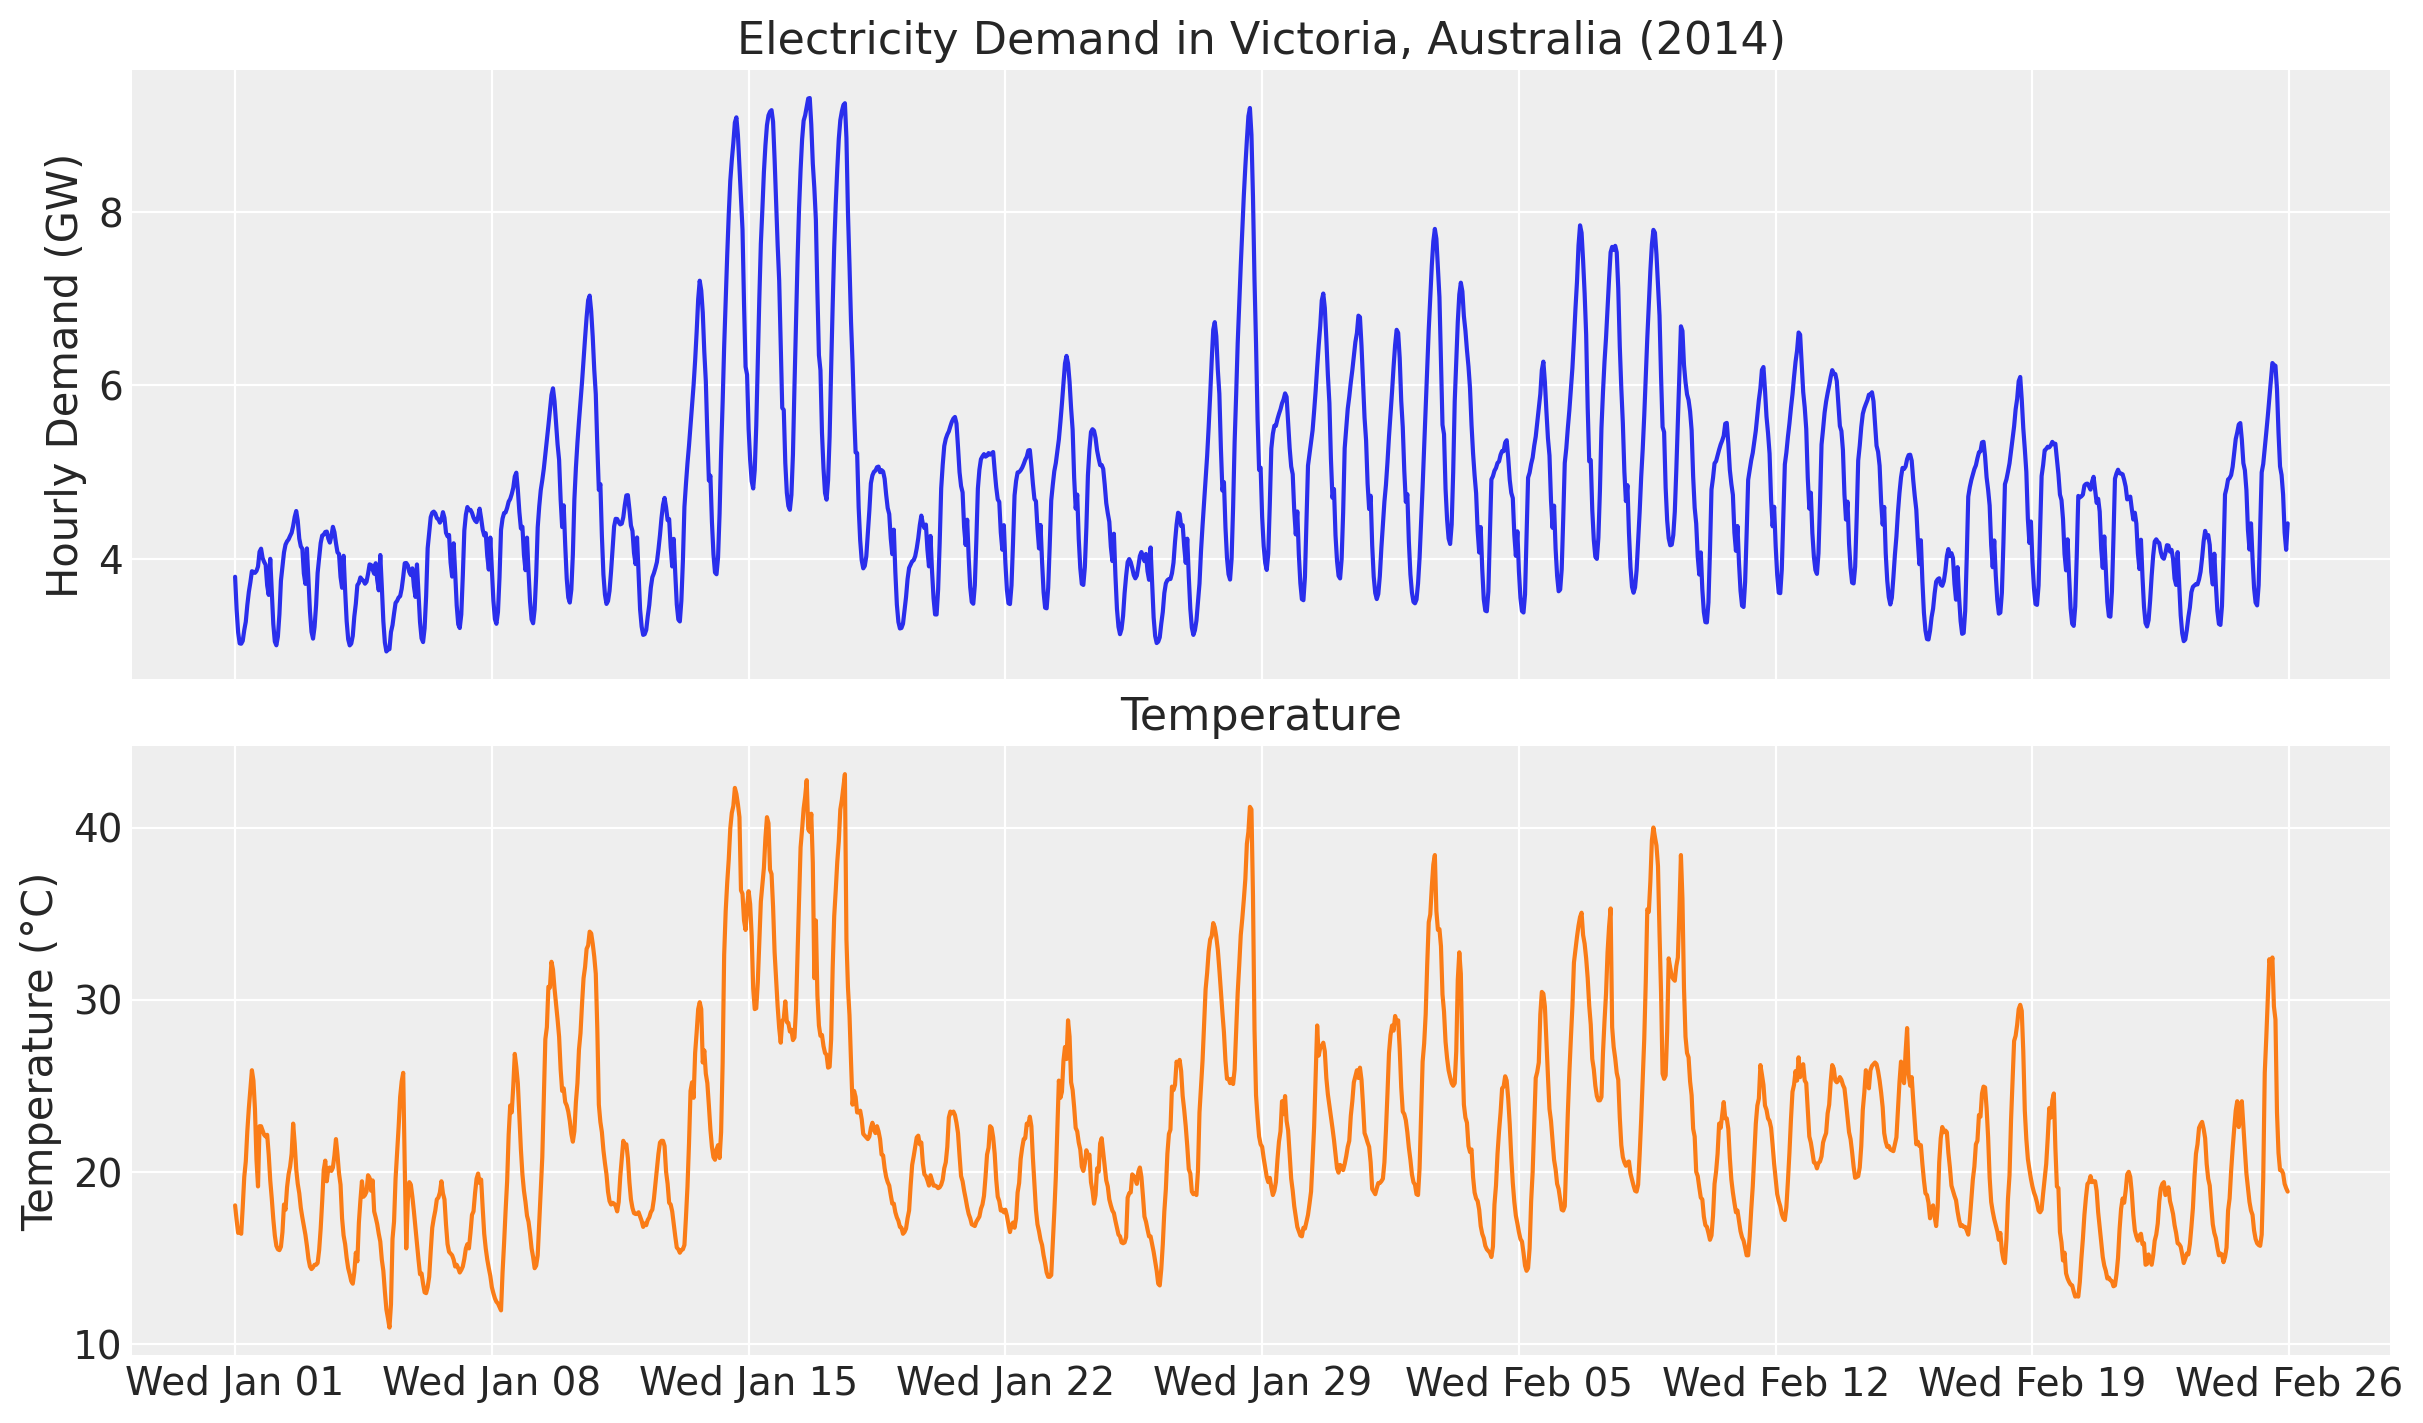

In [3]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=False, layout="constrained")
ax[0].plot(demand_dates, demand_values, c="C0")
ax[0].set(
    title="Electricity Demand in Victoria, Australia (2014)",
    ylabel="Hourly Demand (GW)",
)
ax[1].plot(demand_dates, temperature_values, c="C1")
ax[1].set(title="Temperature", ylabel="Temperature (°C)")
ax[1].xaxis.set_major_locator(demand_loc)
ax[1].xaxis.set_major_formatter(demand_fmt)

We clearly see an overall positive correlation between temperature and electricity demand. This can be particularly seen when we plot both demand and temperature in the same (twin) axis.

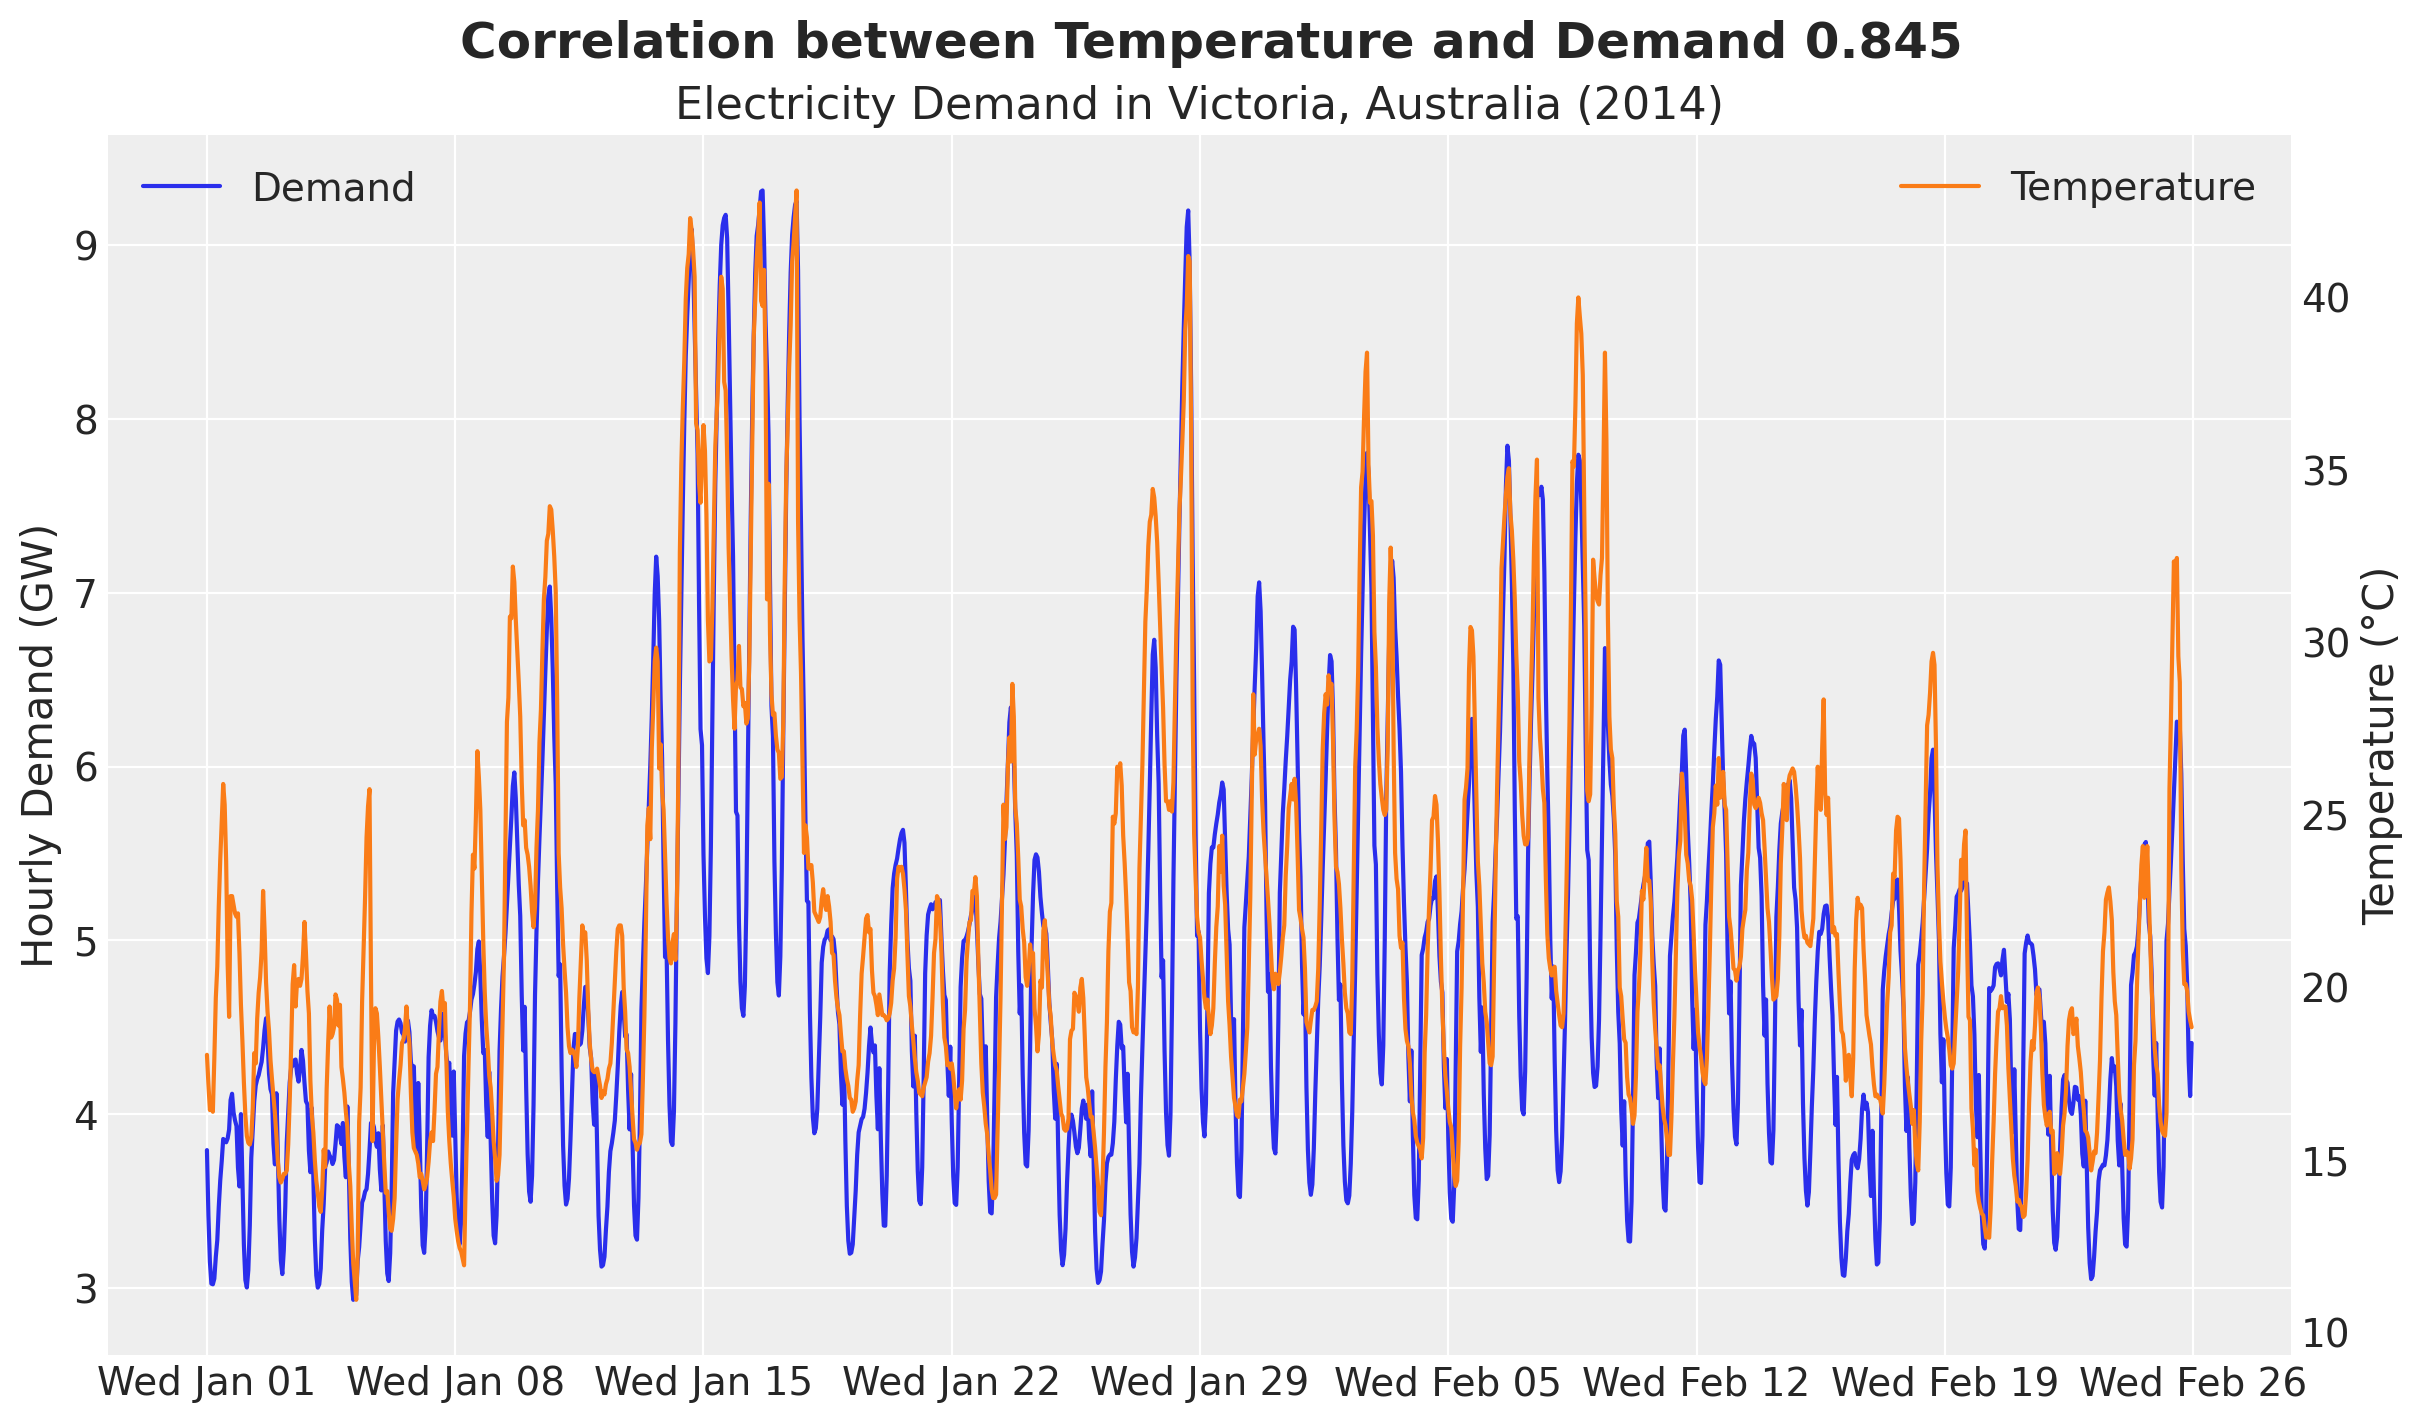

In [4]:
fig, ax = plt.subplots()
ax_twinx = ax.twinx()
ax.plot(demand_dates, demand_values, c="C0", label="Demand")
ax.set(
    title="Electricity Demand in Victoria, Australia (2014)",
    ylabel="Hourly Demand (GW)",
)
ax_twinx.plot(demand_dates, temperature_values, c="C1", label="Temperature")
ax_twinx.set(ylabel="Temperature (°C)")
ax.xaxis.set_major_locator(demand_loc)
ax.xaxis.set_major_formatter(demand_fmt)
ax_twinx.grid(None)
ax.legend(loc="upper left")
ax_twinx.legend(loc="upper right")
corr = np.corrcoef(temperature_values, demand_values)[0, 1]
fig.suptitle(
    f"Correlation between Temperature and Demand {corr:.3f}",
    fontsize=18,
    fontweight="bold",
);

Besides forecasting, we would also like to understand the relationship between temperature and electricity demand. A good first starting point is to generate a scatter plot of temperature and demand.

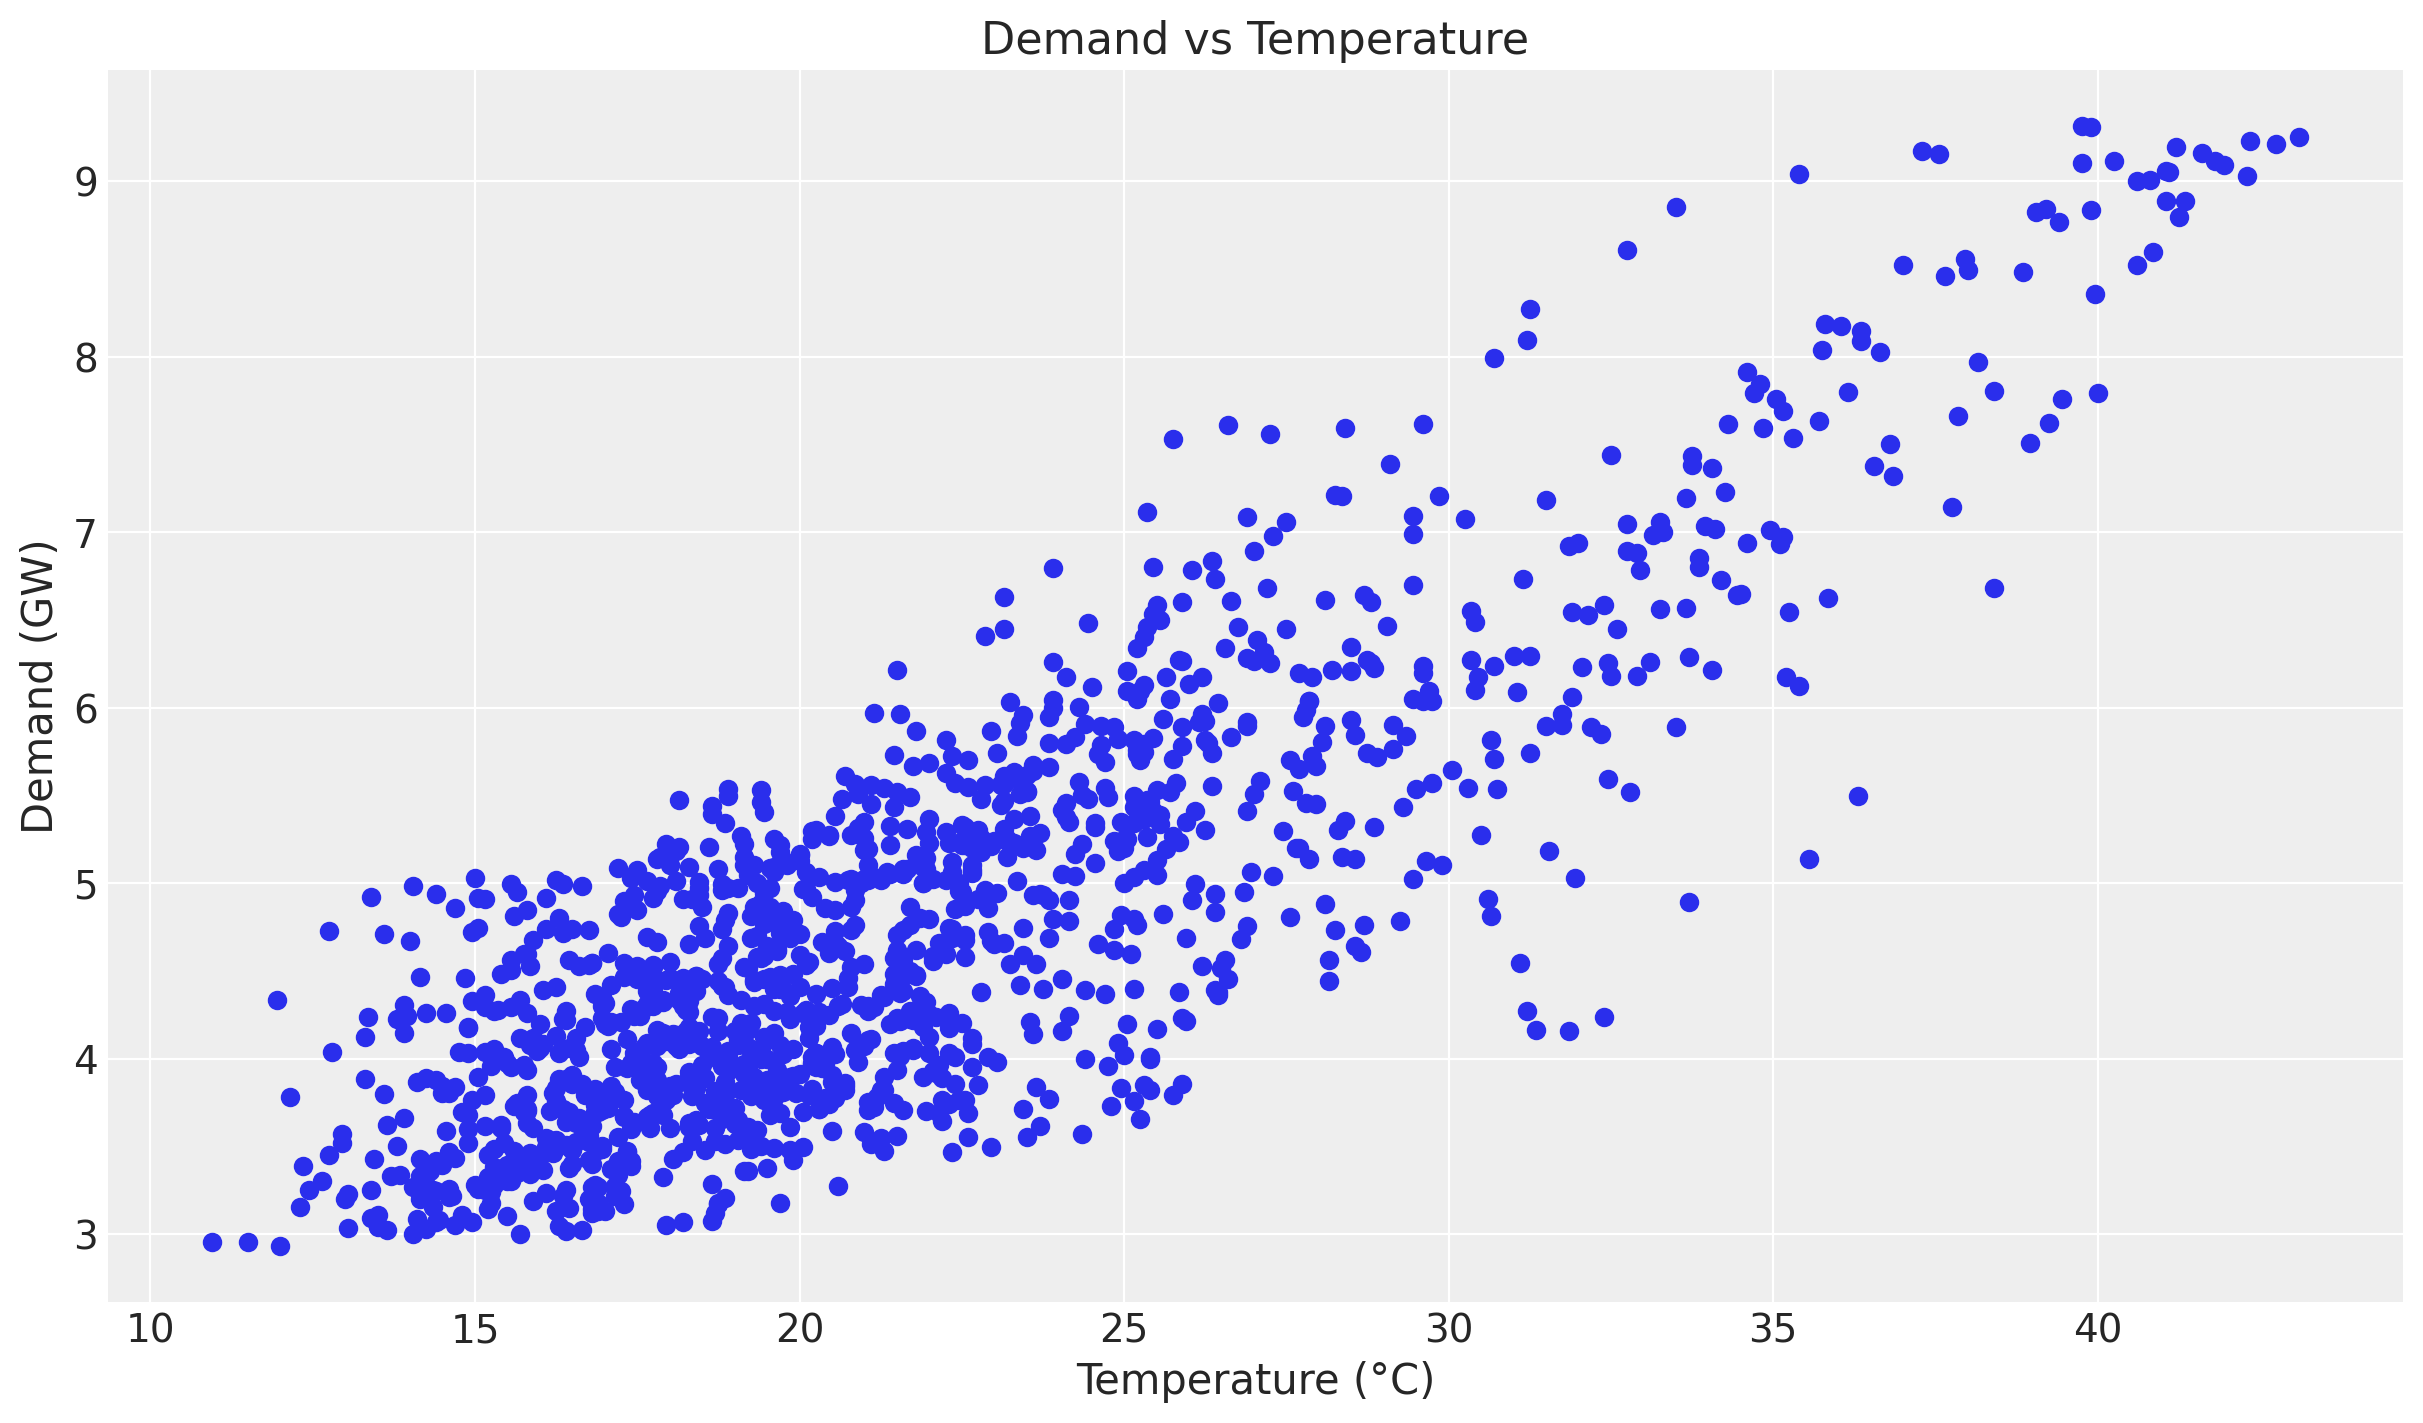

In [5]:
fig, ax = plt.subplots()
ax.scatter(temperature_values, demand_values)
ax.set(title="Demand vs Temperature", xlabel="Temperature (°C)", ylabel="Demand (GW)");

Even though we see a positive relationship between temperature and demand, the relationship is not linear. We can see this by plotting the ratio of demand to temperature.

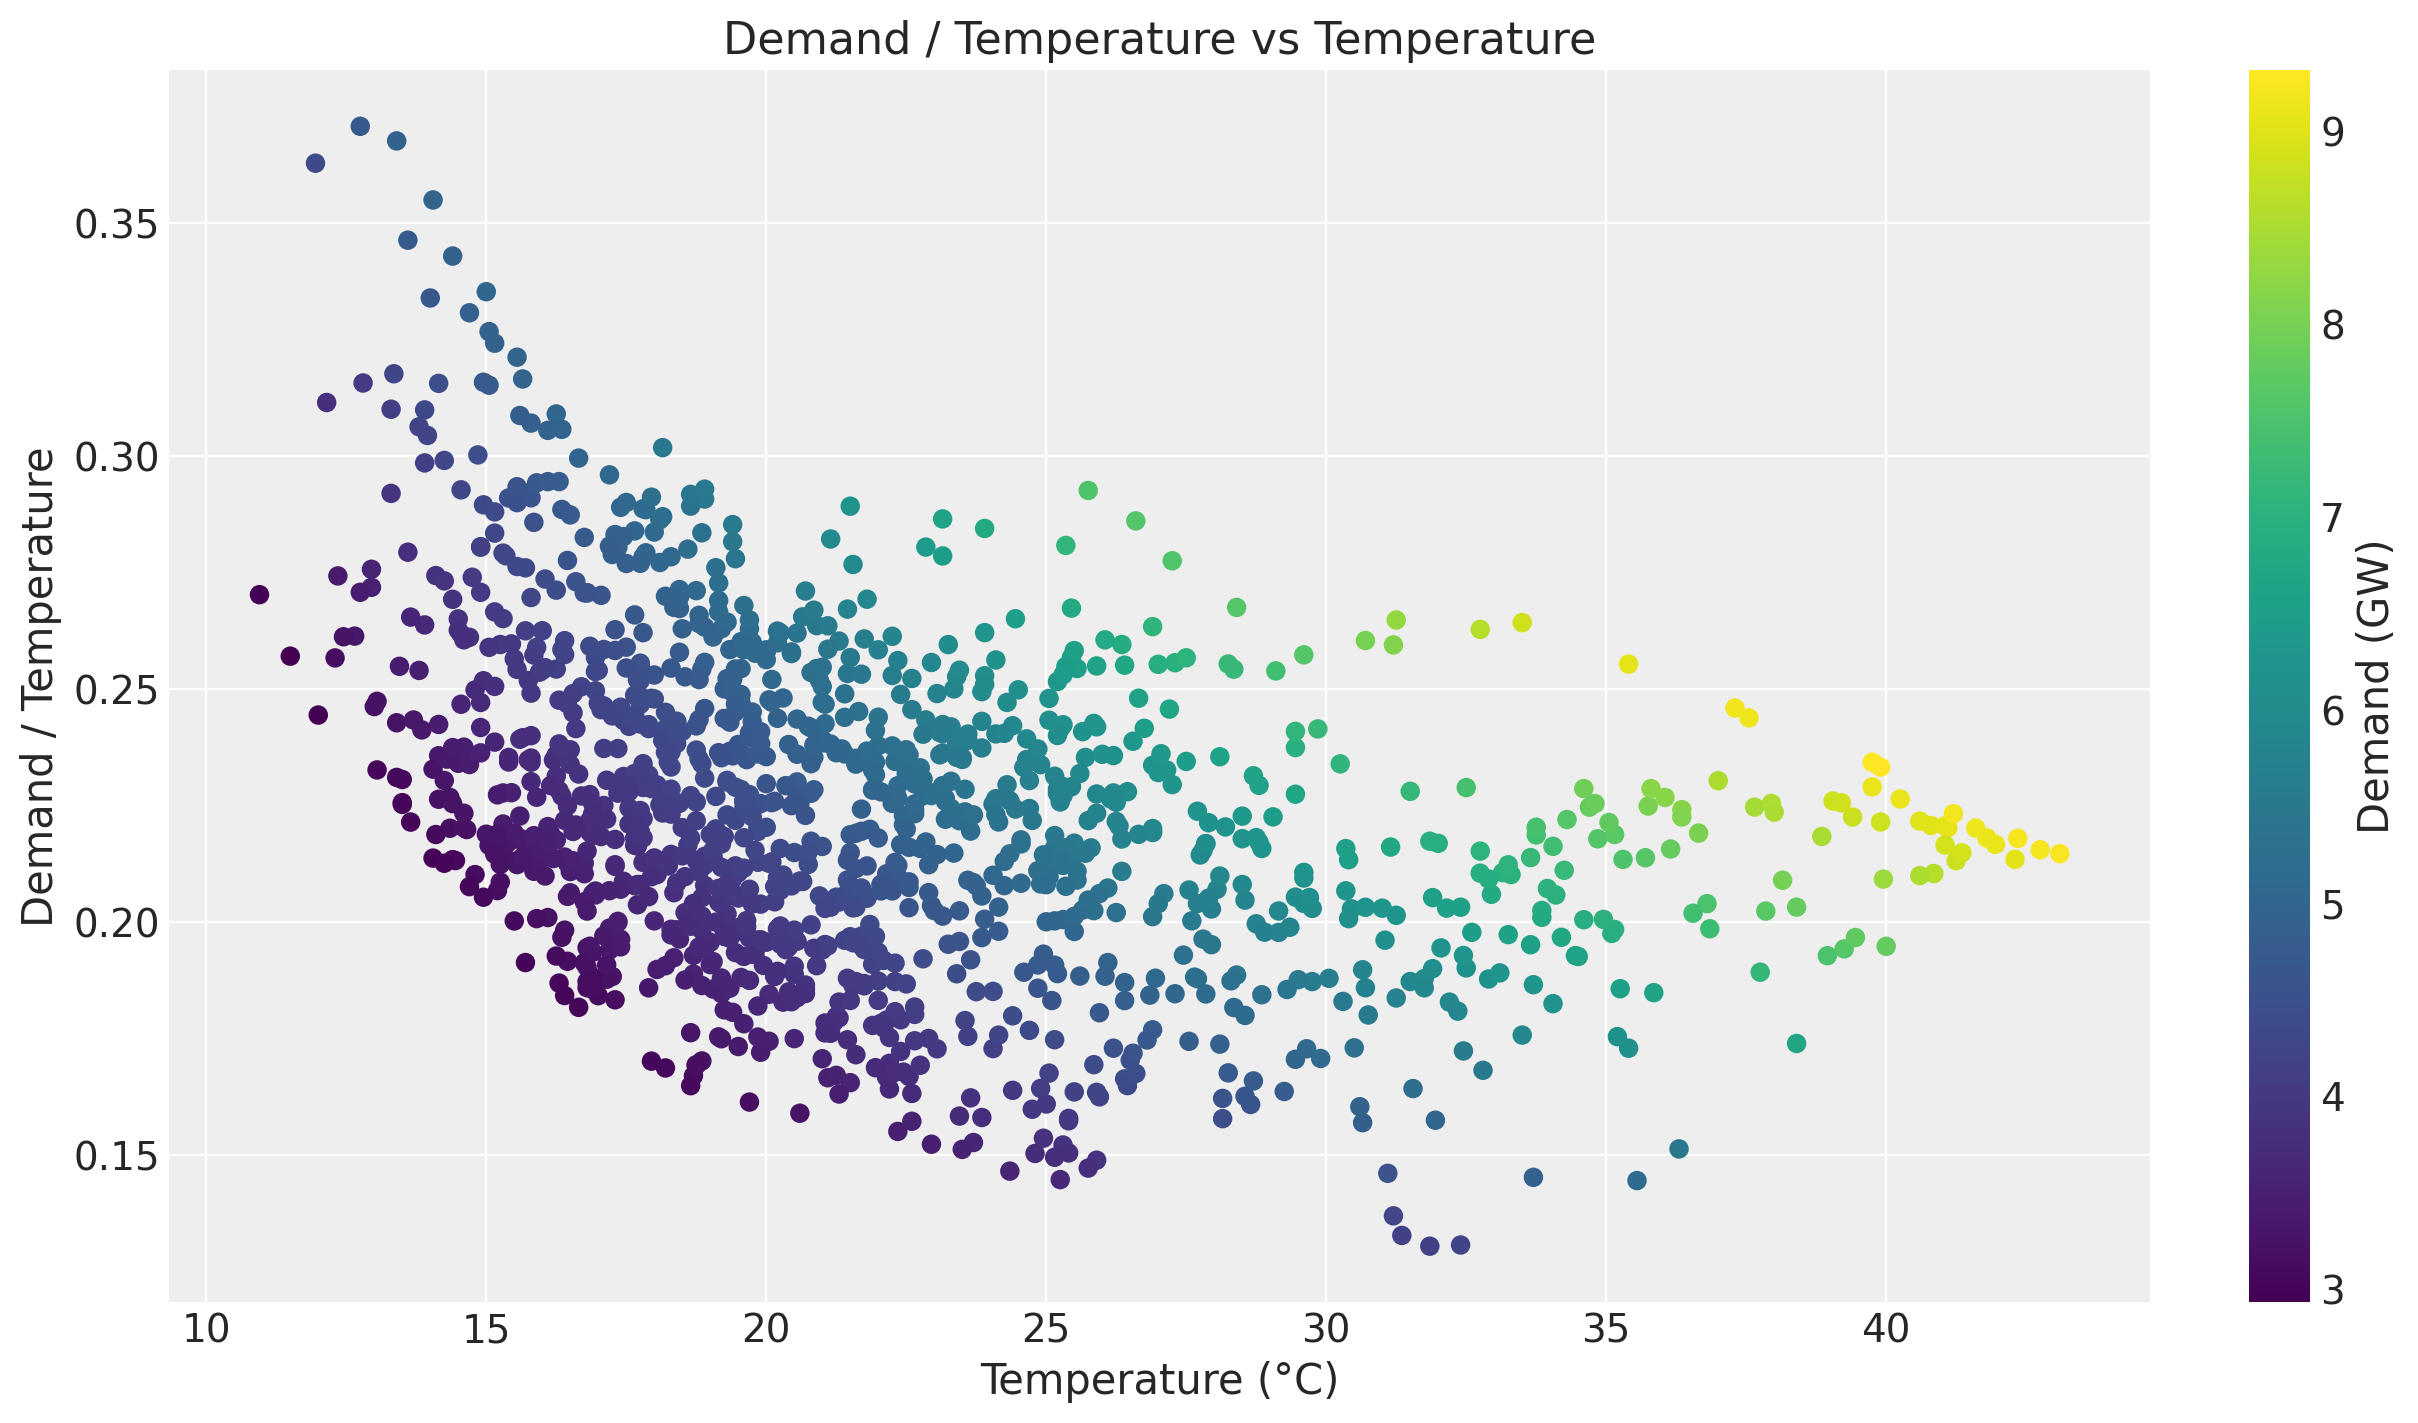

In [6]:
fig, ax = plt.subplots()
ax.scatter(temperature_values, demand_values / temperature_values, c=demand_values, cmap="viridis")
cbar = fig.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Demand (GW)")
ax.set(
    title="Demand / Temperature vs Temperature",
    xlabel="Temperature (°C)",
    ylabel="Demand / Temperature",
);

Of course there are strong seasonal effects hidden in these plots. Therefore we want to use a model that can capture the temperature effect while controlling for other factors.

## Training and test data

We split the data as in the original example, holding out the last two weeks. In addition, we build the exogenous inputs the model needs and pack them into a single `covariates` array with time at axis `-2`: the temperature and a `day_of_week` index. The forecast horizon is inferred later from `covariates` being longer than the training data.

In [7]:
num_forecast_steps = 24 * 7 * 2  # two weeks
t_train = duration - num_forecast_steps

data_train = demand[:t_train]
data_test = demand[t_train:]

dates_train = demand_dates[:t_train]
dates_test = demand_dates[t_train:]

day_of_week = np.array([d.weekday() for d in demand_dates.astype("datetime64[D]").astype(object)])

covariates = jnp.stack([temperature, jnp.asarray(day_of_week, dtype=jnp.float32)], axis=-1)
covariates_train = covariates[:t_train]

print("data_train shape:", data_train.shape)
print("data_test shape:", data_test.shape)
print("covariates shape:", covariates.shape)

data_train shape: (1008, 1)
data_test shape: (336, 1)
covariates shape: (1344, 2)


We can now visualize the training and test split of the demand.

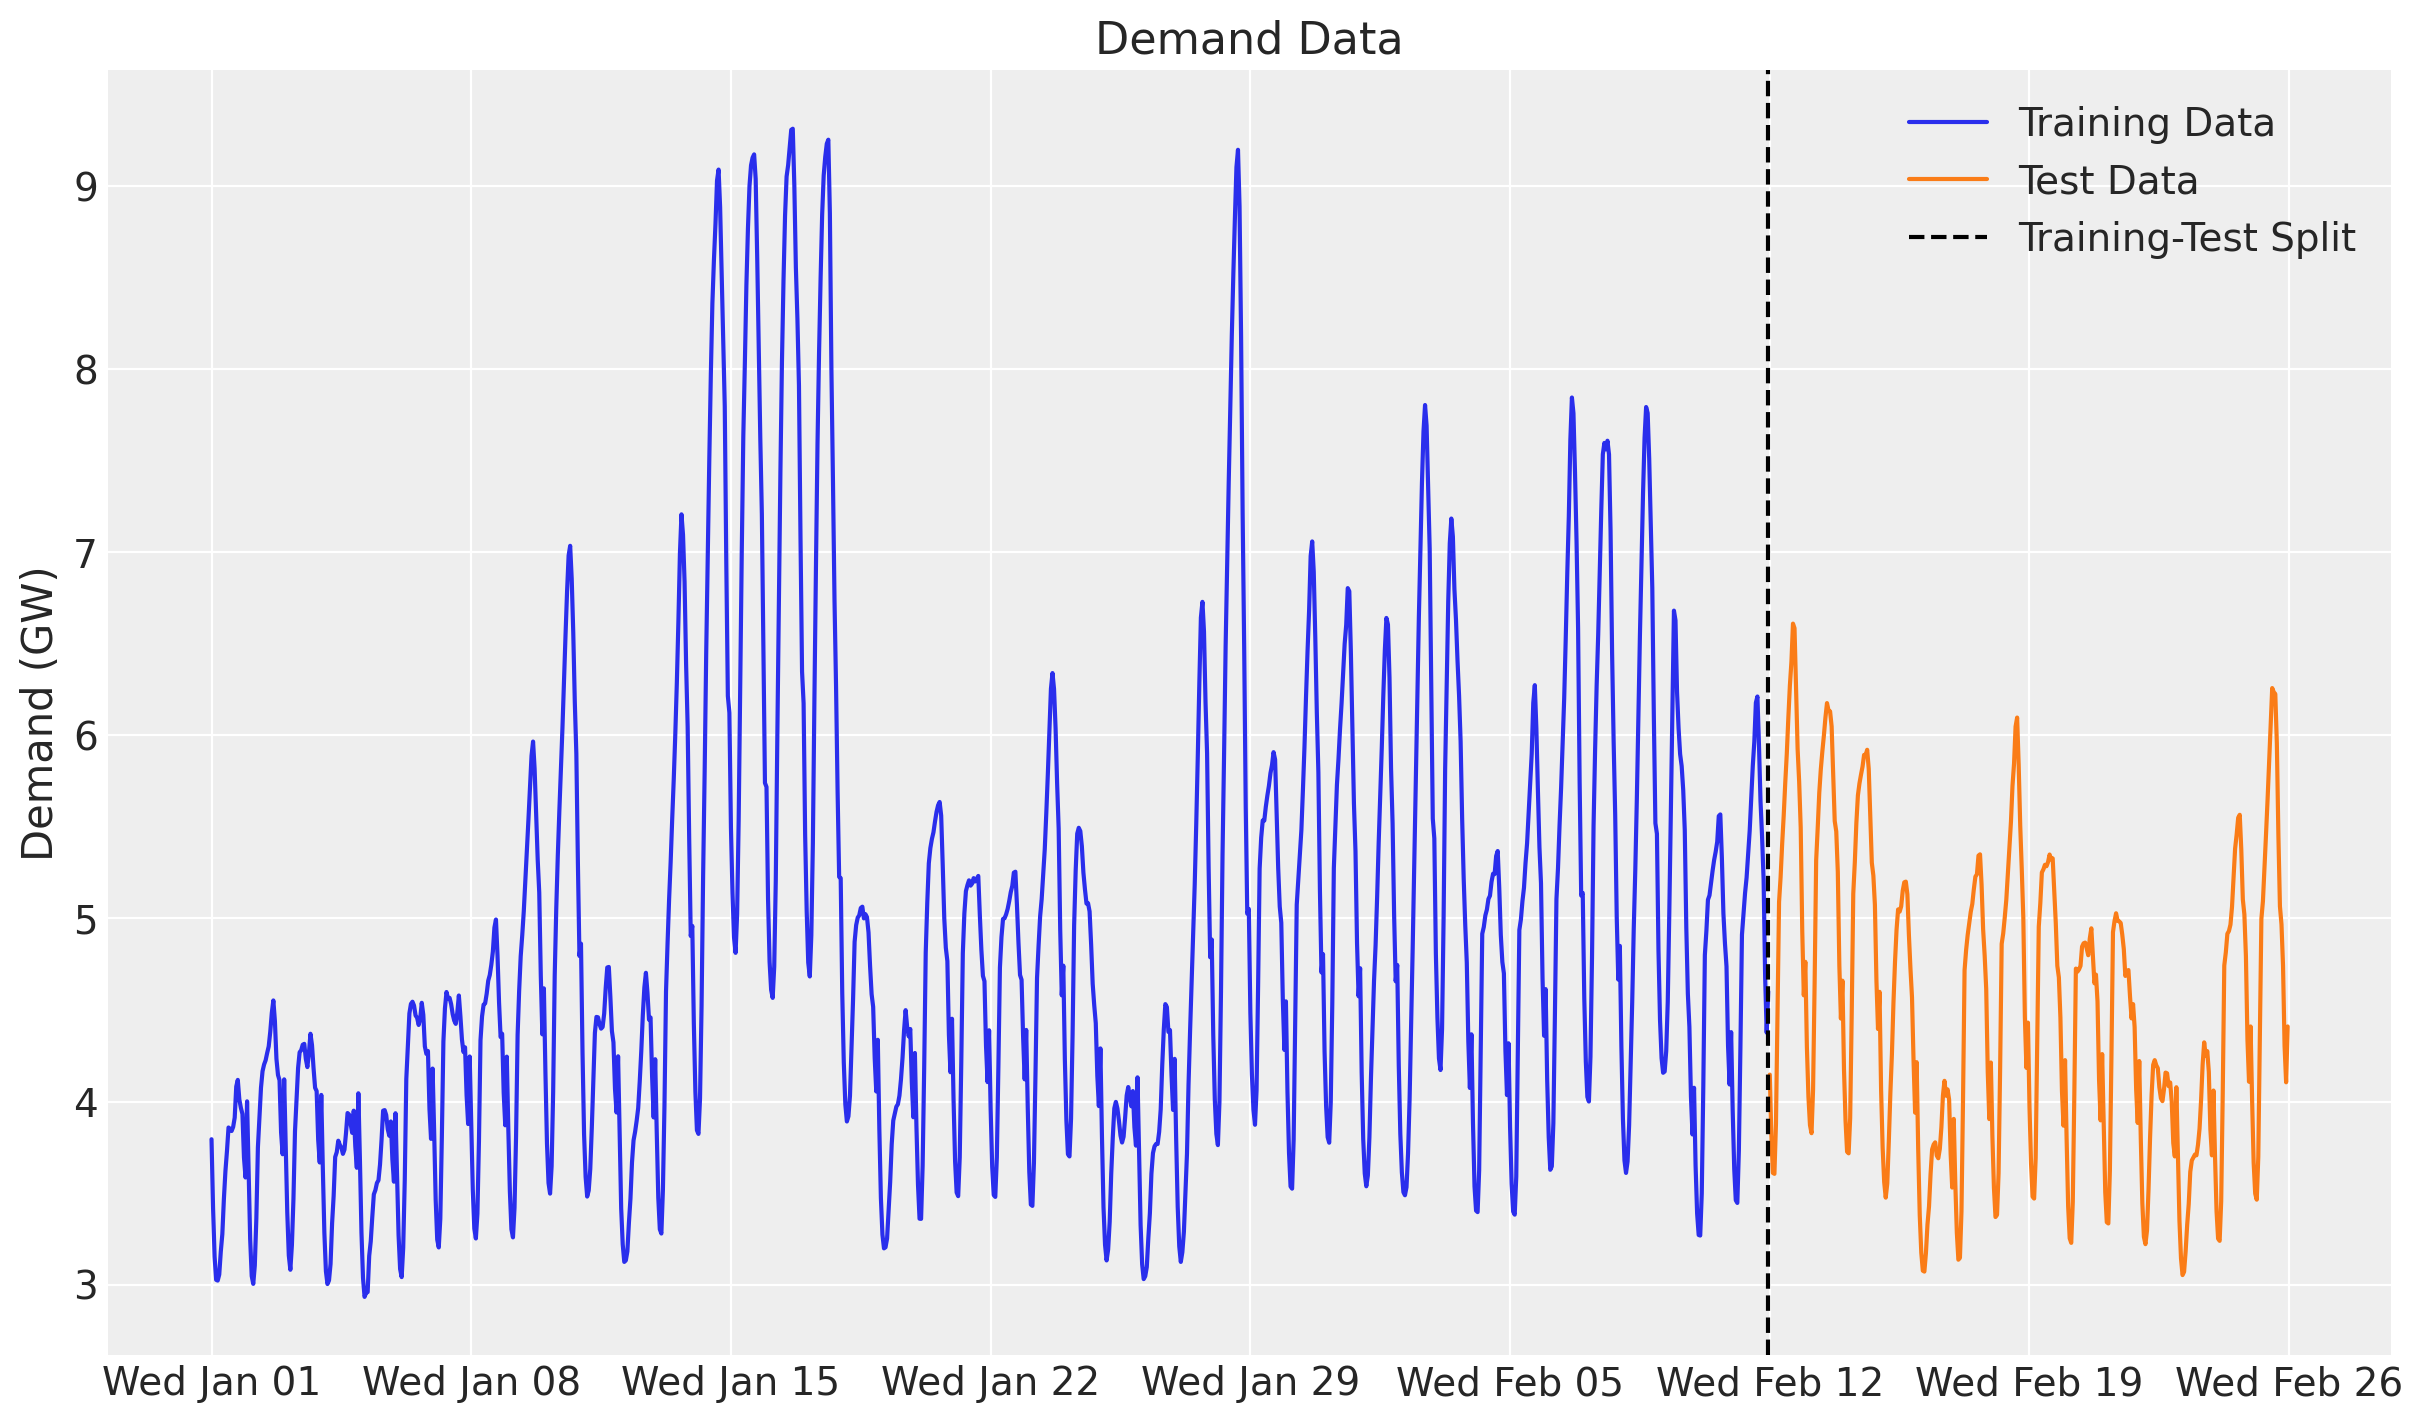

In [8]:
fig, ax = plt.subplots()
ax.plot(dates_train, np.asarray(data_train[:, 0]), label="Training Data")
ax.plot(dates_test, np.asarray(data_test[:, 0]), label="Test Data")
ax.axvline(x=dates_train[-1], color="black", linestyle="--", label="Training-Test Split")
ax.set(title="Demand Data", ylabel="Demand (GW)")
ax.legend()
ax.xaxis.set_major_locator(demand_loc)
ax.xaxis.set_major_formatter(demand_fmt)

## Model specification

Here is the modeling strategy, re-expressed as a plain NumPyro model function built with the `numpyro_forecast` `predict` building block:

- A linear-in-features model predicts demand from temperature and two seasonal effects, hour of day and day of week, both modeled with Zero-Sum Normal distributions.
- A Matérn 5/2 kernel models the temperature effect on demand through the Hilbert Space Gaussian Process (HSGP) approximation from NumPyro (see [here](https://num.pyro.ai/en/stable/contrib.html#hilbert-space-gaussian-processes-approximation)).
- The noise scale varies with the temperature.
- A Student-t distribution models the residual error.

The model function `(covariates, data=None)` opens with `Horizon.from_data(covariates, data)`, which derives the training window and the forecast horizon from the two shapes, reads its exogenous inputs from `covariates`, and calls `predict` exactly once with a zero-centered noise distribution and the deterministic mean. Because there is no random-walk latent here (the temperature and calendar are known over the whole horizon), the model is purely covariate-driven and `predict` handles both the in-sample fit (the `obs` site) and the forecast suffix (`obs_future` and the `forecast` deterministic), including the per-timestep noise scale. The HSGP boundary factor and the number of basis functions are fixed module constants.

### GP prior parameters

One key component of specifying Gaussian processes is to set the length scale and amplitude parameters. We use an optimization strategy (`preliz`) to set these parameters by assuming they both come from an Inverse-Gamma distribution while specifying the support.

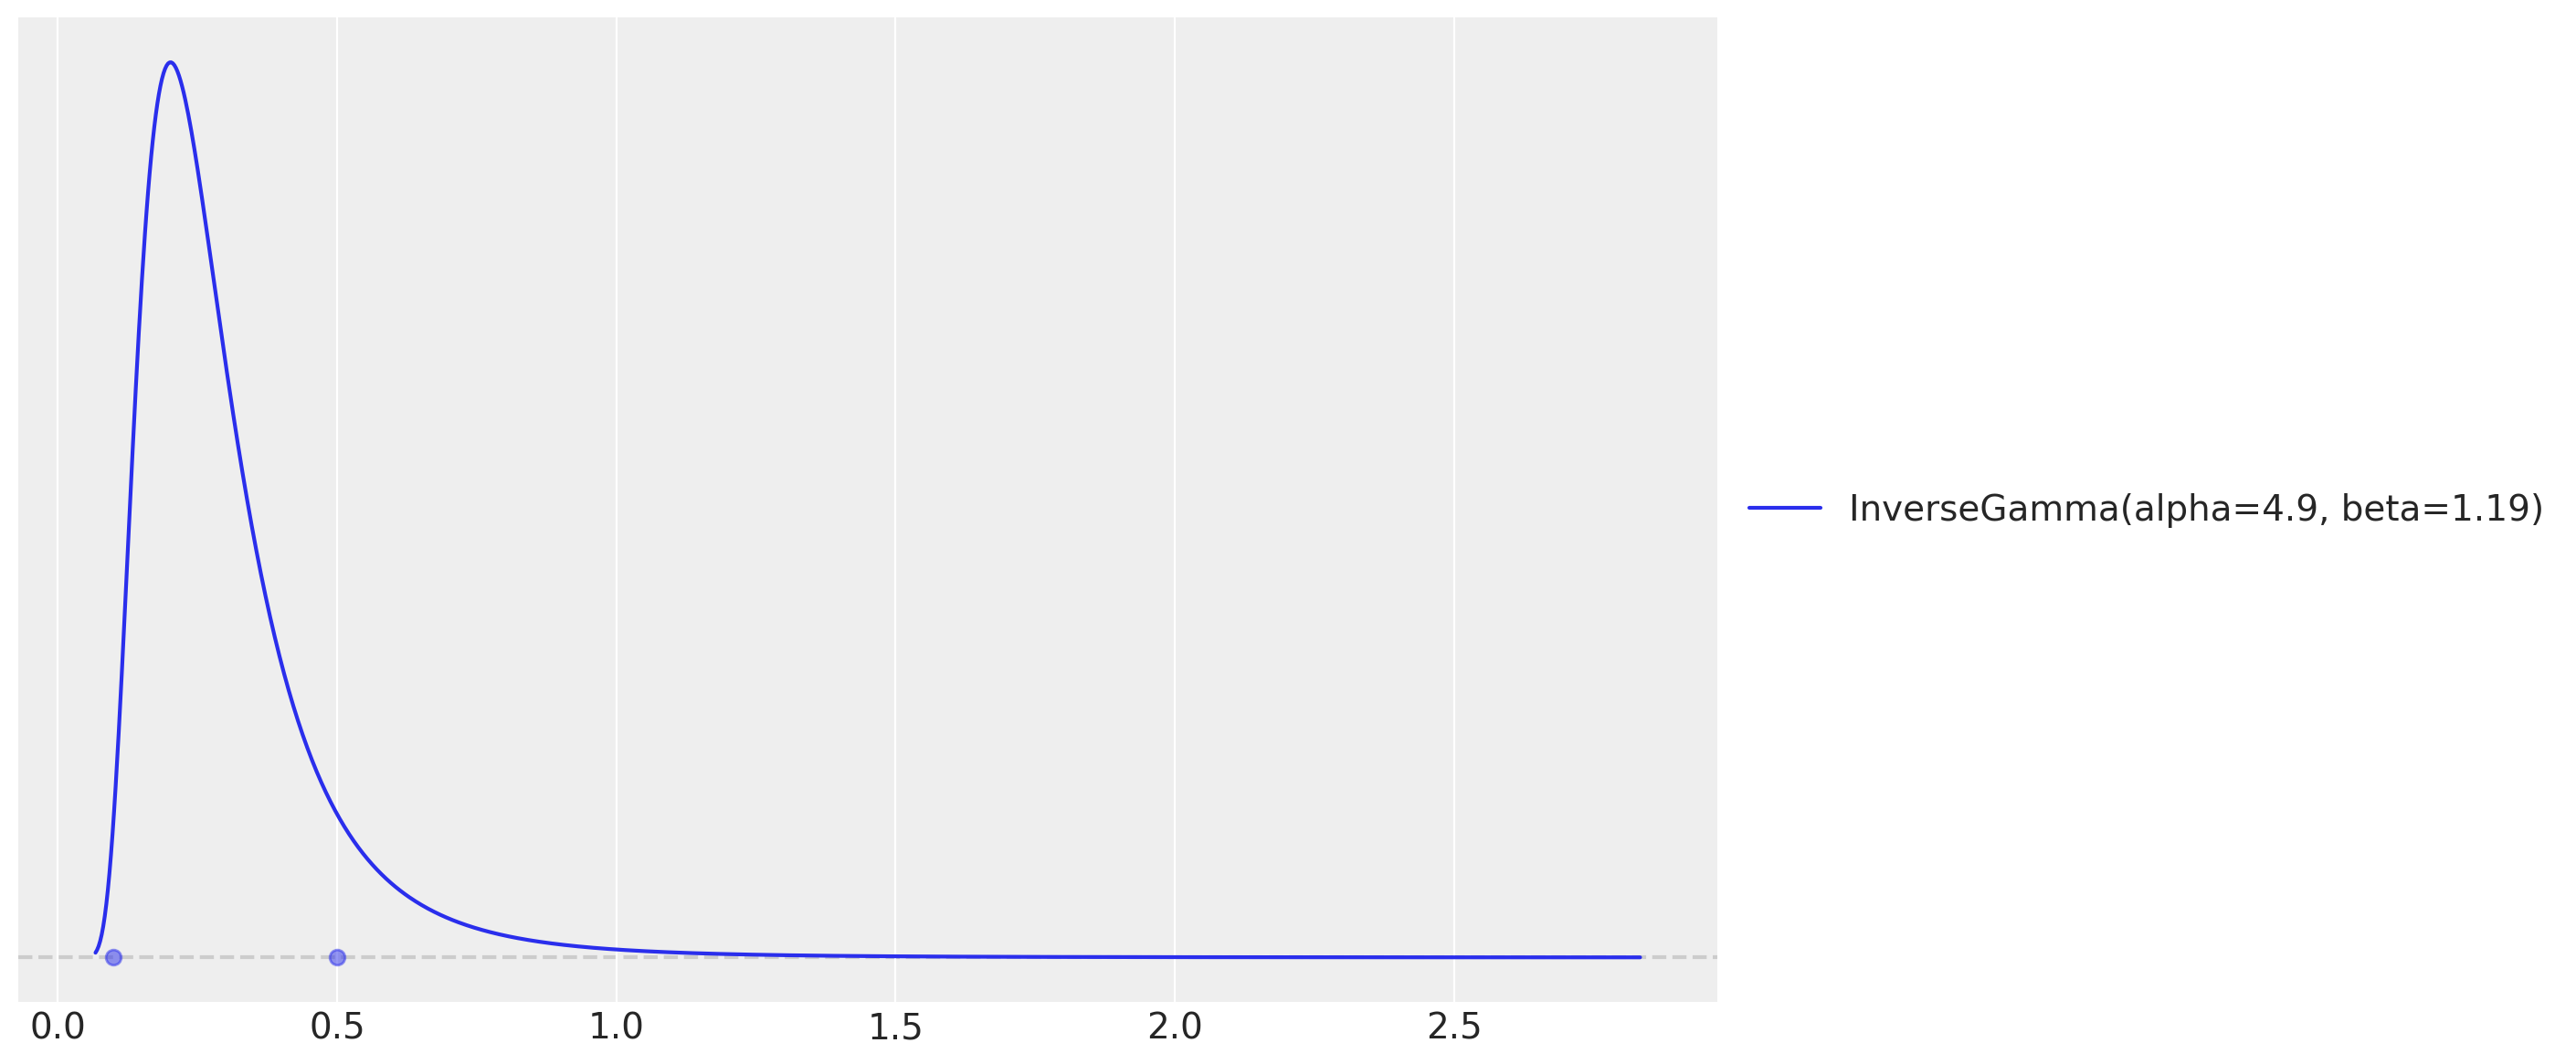

In [9]:
# For the amplitude, we set the values inspired on the range of the demand / temperature
# ratio above.
amplitude_params, ax = pz.maxent(pz.InverseGamma(), lower=0.1, upper=0.5)

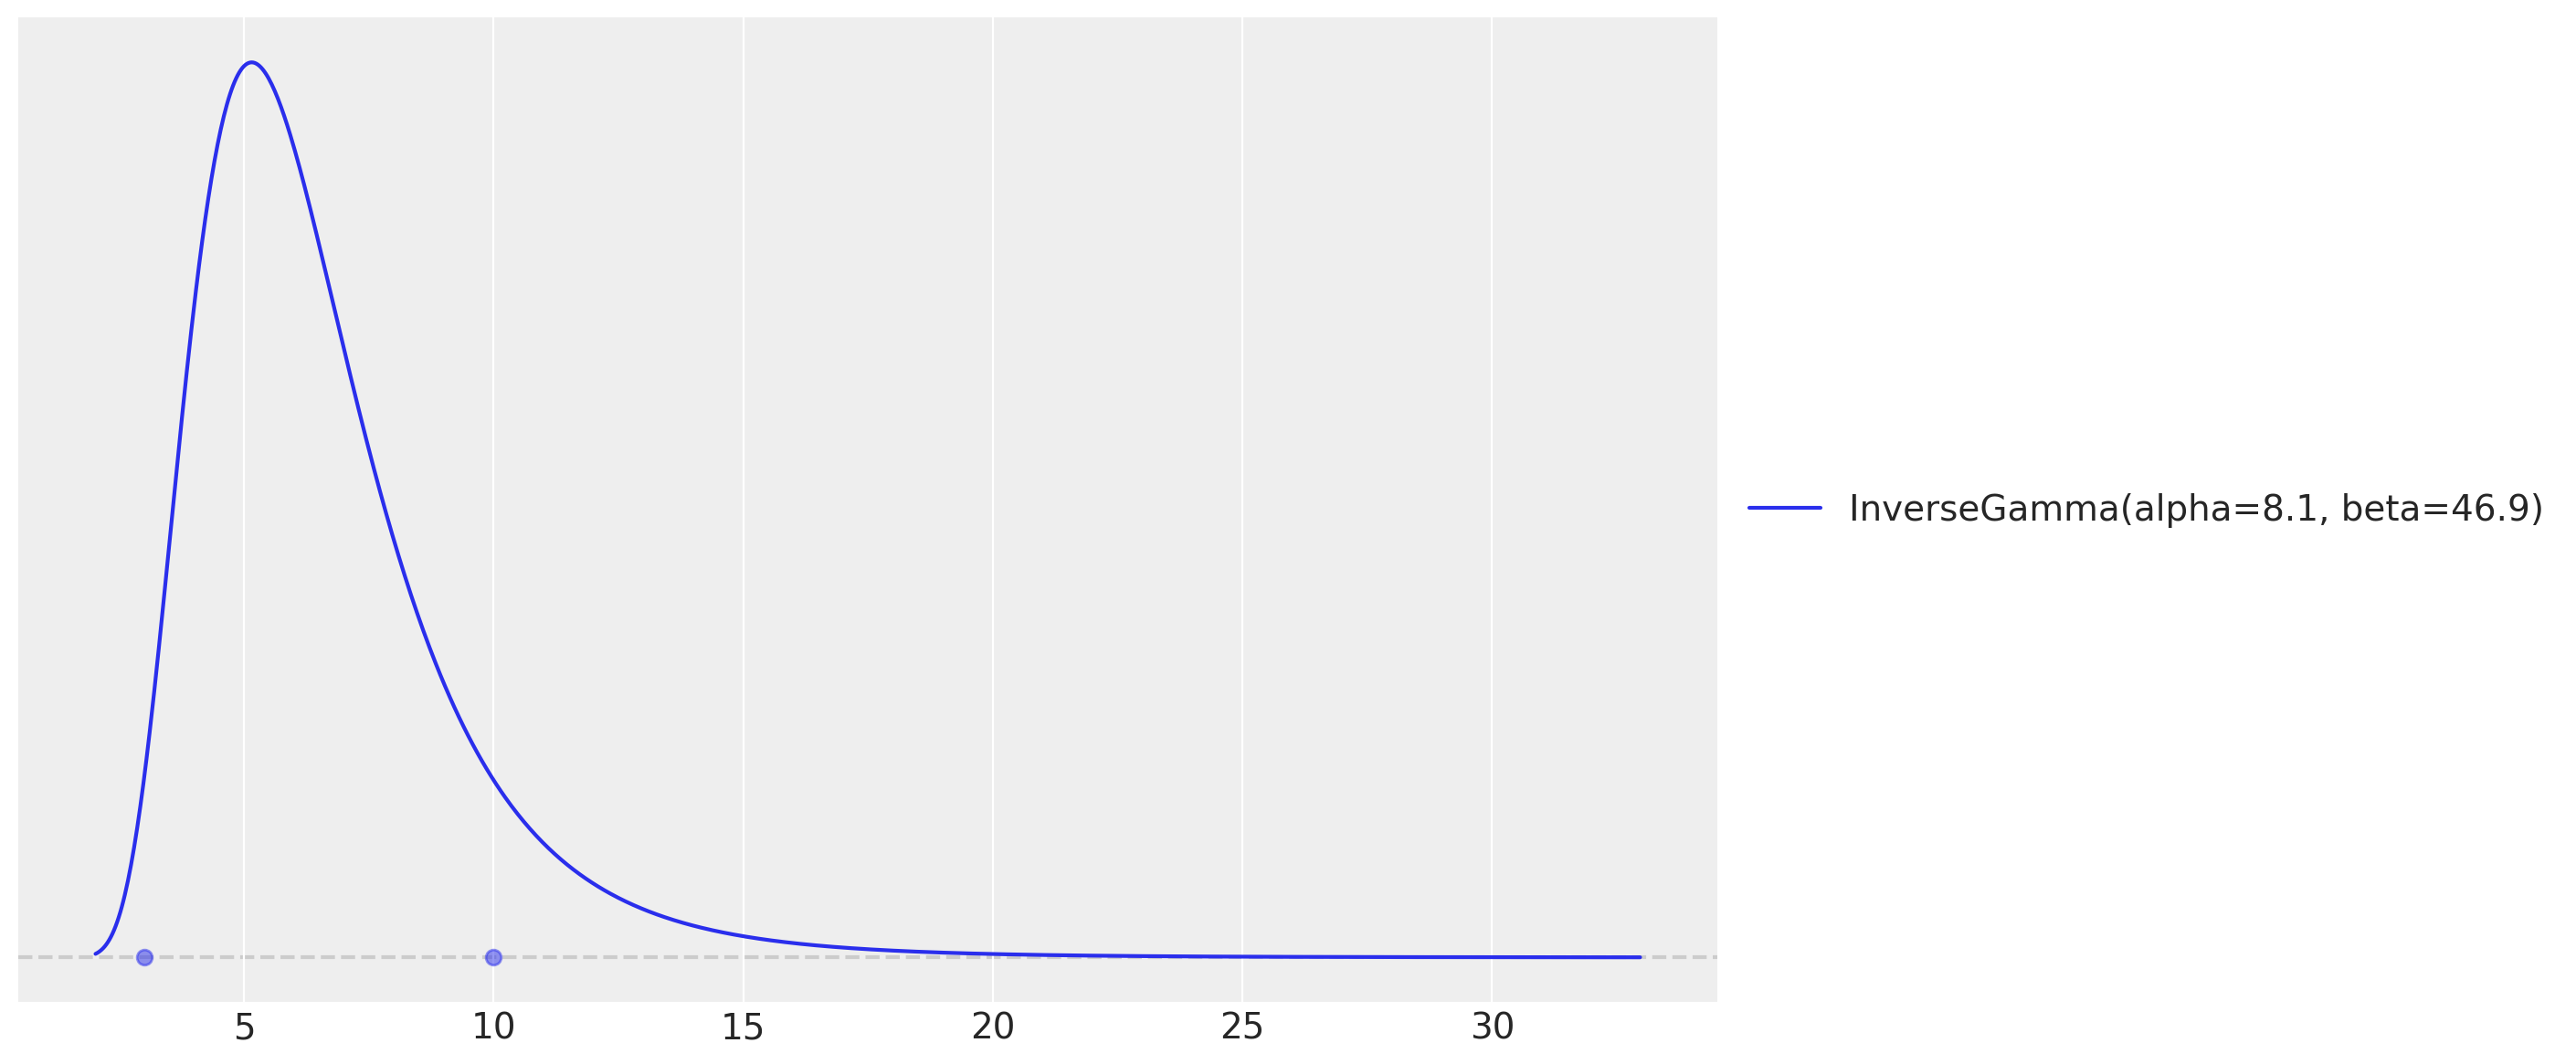

In [10]:
# As we want to use the GP to model the temperature effect, we need to set the length
# scale parameter. We expect these effects to be seen at the order of units or tens of
# units, so we expect the length scale to be between 3 and 10.
length_scale_params, ax = pz.maxent(pz.InverseGamma(), lower=3, upper=10)

These two `maxent` calls return the Inverse-Gamma parameters we plug into the model below (the hour-of-day effect is tiled over the horizon with the package helper `periodic_repeat`).

In [11]:
ELL = 55.0  # HSGP boundary factor
M = 25  # number of HSGP basis functions


def electricity_model(covariates: Array, data: Array | None = None) -> None:
    """HSGP temperature effect plus hour/day seasonality with a Student-t likelihood."""
    h = Horizon.from_data(covariates, data)
    duration = covariates.shape[-2]
    temperature = covariates[..., 0]
    day_of_week = covariates[..., 1].astype("int32")

    # Intercept.
    intercept = numpyro.sample("intercept", dist.Normal(loc=0.0, scale=2.0))

    # GP parameters (amplitude and length-scale priors are the preliz maxent fits).
    alpha = numpyro.sample("alpha", dist.InverseGamma(concentration=6.66, rate=1.57))
    length_scale = numpyro.sample("length_scale", dist.InverseGamma(concentration=11.0, rate=62.2))
    scale_factor = numpyro.sample("scale", dist.HalfNormal(scale=0.5))
    # Degrees of freedom for the Student-t likelihood.
    nu = numpyro.sample("nu", dist.Gamma(concentration=8.0, rate=3.0))

    # Non-linear temperature effect as a Matérn 5/2 HSGP. ``hsgp_matern`` is
    # annotated for float hyperparameters, so we cast the sampled scalars.
    beta_temperature = hsgp_matern(
        x=temperature,
        nu=5 / 2,
        alpha=cast("float", alpha),
        length=cast("float", length_scale),
        ell=ELL,
        m=M,
    )
    numpyro.deterministic("beta_temperature", beta_temperature)

    # Hour-of-day effect, tiled over the horizon with periodic_repeat.
    scale_hour_of_day = numpyro.sample("scale_hour_of_day", dist.HalfNormal(scale=0.5))
    hour_of_day_effect = numpyro.sample(
        "hour_of_day_effect",
        dist.ZeroSumNormal(scale=scale_hour_of_day, event_shape=(24,)),
    )
    hour_of_day_effect = periodic_repeat(hour_of_day_effect, duration, axis=-1)

    # Day-of-week effect, indexed by the calendar covariate.
    scale_day_of_week = numpyro.sample("scale_day_of_week", dist.HalfNormal(scale=0.5))
    day_of_week_effect = numpyro.sample(
        "day_of_week_effect",
        dist.ZeroSumNormal(scale=scale_day_of_week, event_shape=(7,)),
    )

    # Expected demand and a temperature-dependent Student-t noise scale.
    mu = (
        beta_temperature * temperature
        + intercept
        + hour_of_day_effect
        + jnp.take(day_of_week_effect, day_of_week)
    )
    scale = scale_factor * jnp.sqrt(temperature)

    predict(h, dist.StudentT(df=nu, loc=0.0, scale=scale[..., None]), mu[..., None])

The model function is a plain NumPyro model callable `(covariates, data=None)`, so we can render its structure directly.

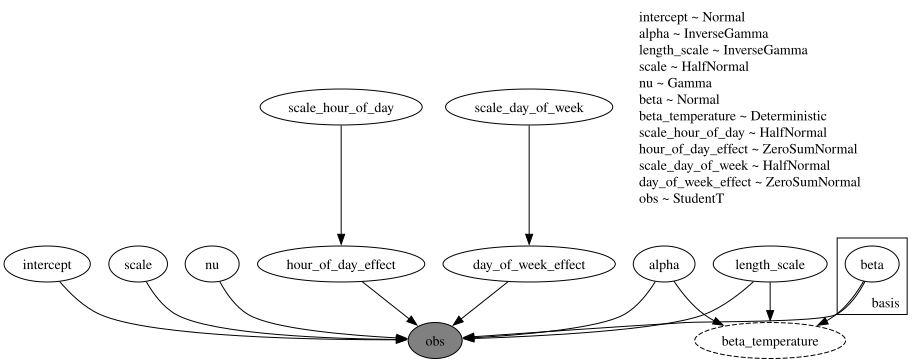

In [12]:
numpyro.render_model(
    electricity_model,
    model_args=(covariates_train, data_train),
    render_distributions=True,
    render_params=True,
)

## Prior predictive checks

Before we fit the model, let's visualize the prior predictive distribution. The model function is a plain NumPyro model, so we hand it to `Predictive` directly. We draw the bands with ArviZ's `plot_lm`, which computes the $50\%$ and $94\%$ HDI internally; since the time axis is a `datetime64` array we pass it as matplotlib date numbers (`mdates.date2num`) and restore the date formatter on the returned axis.

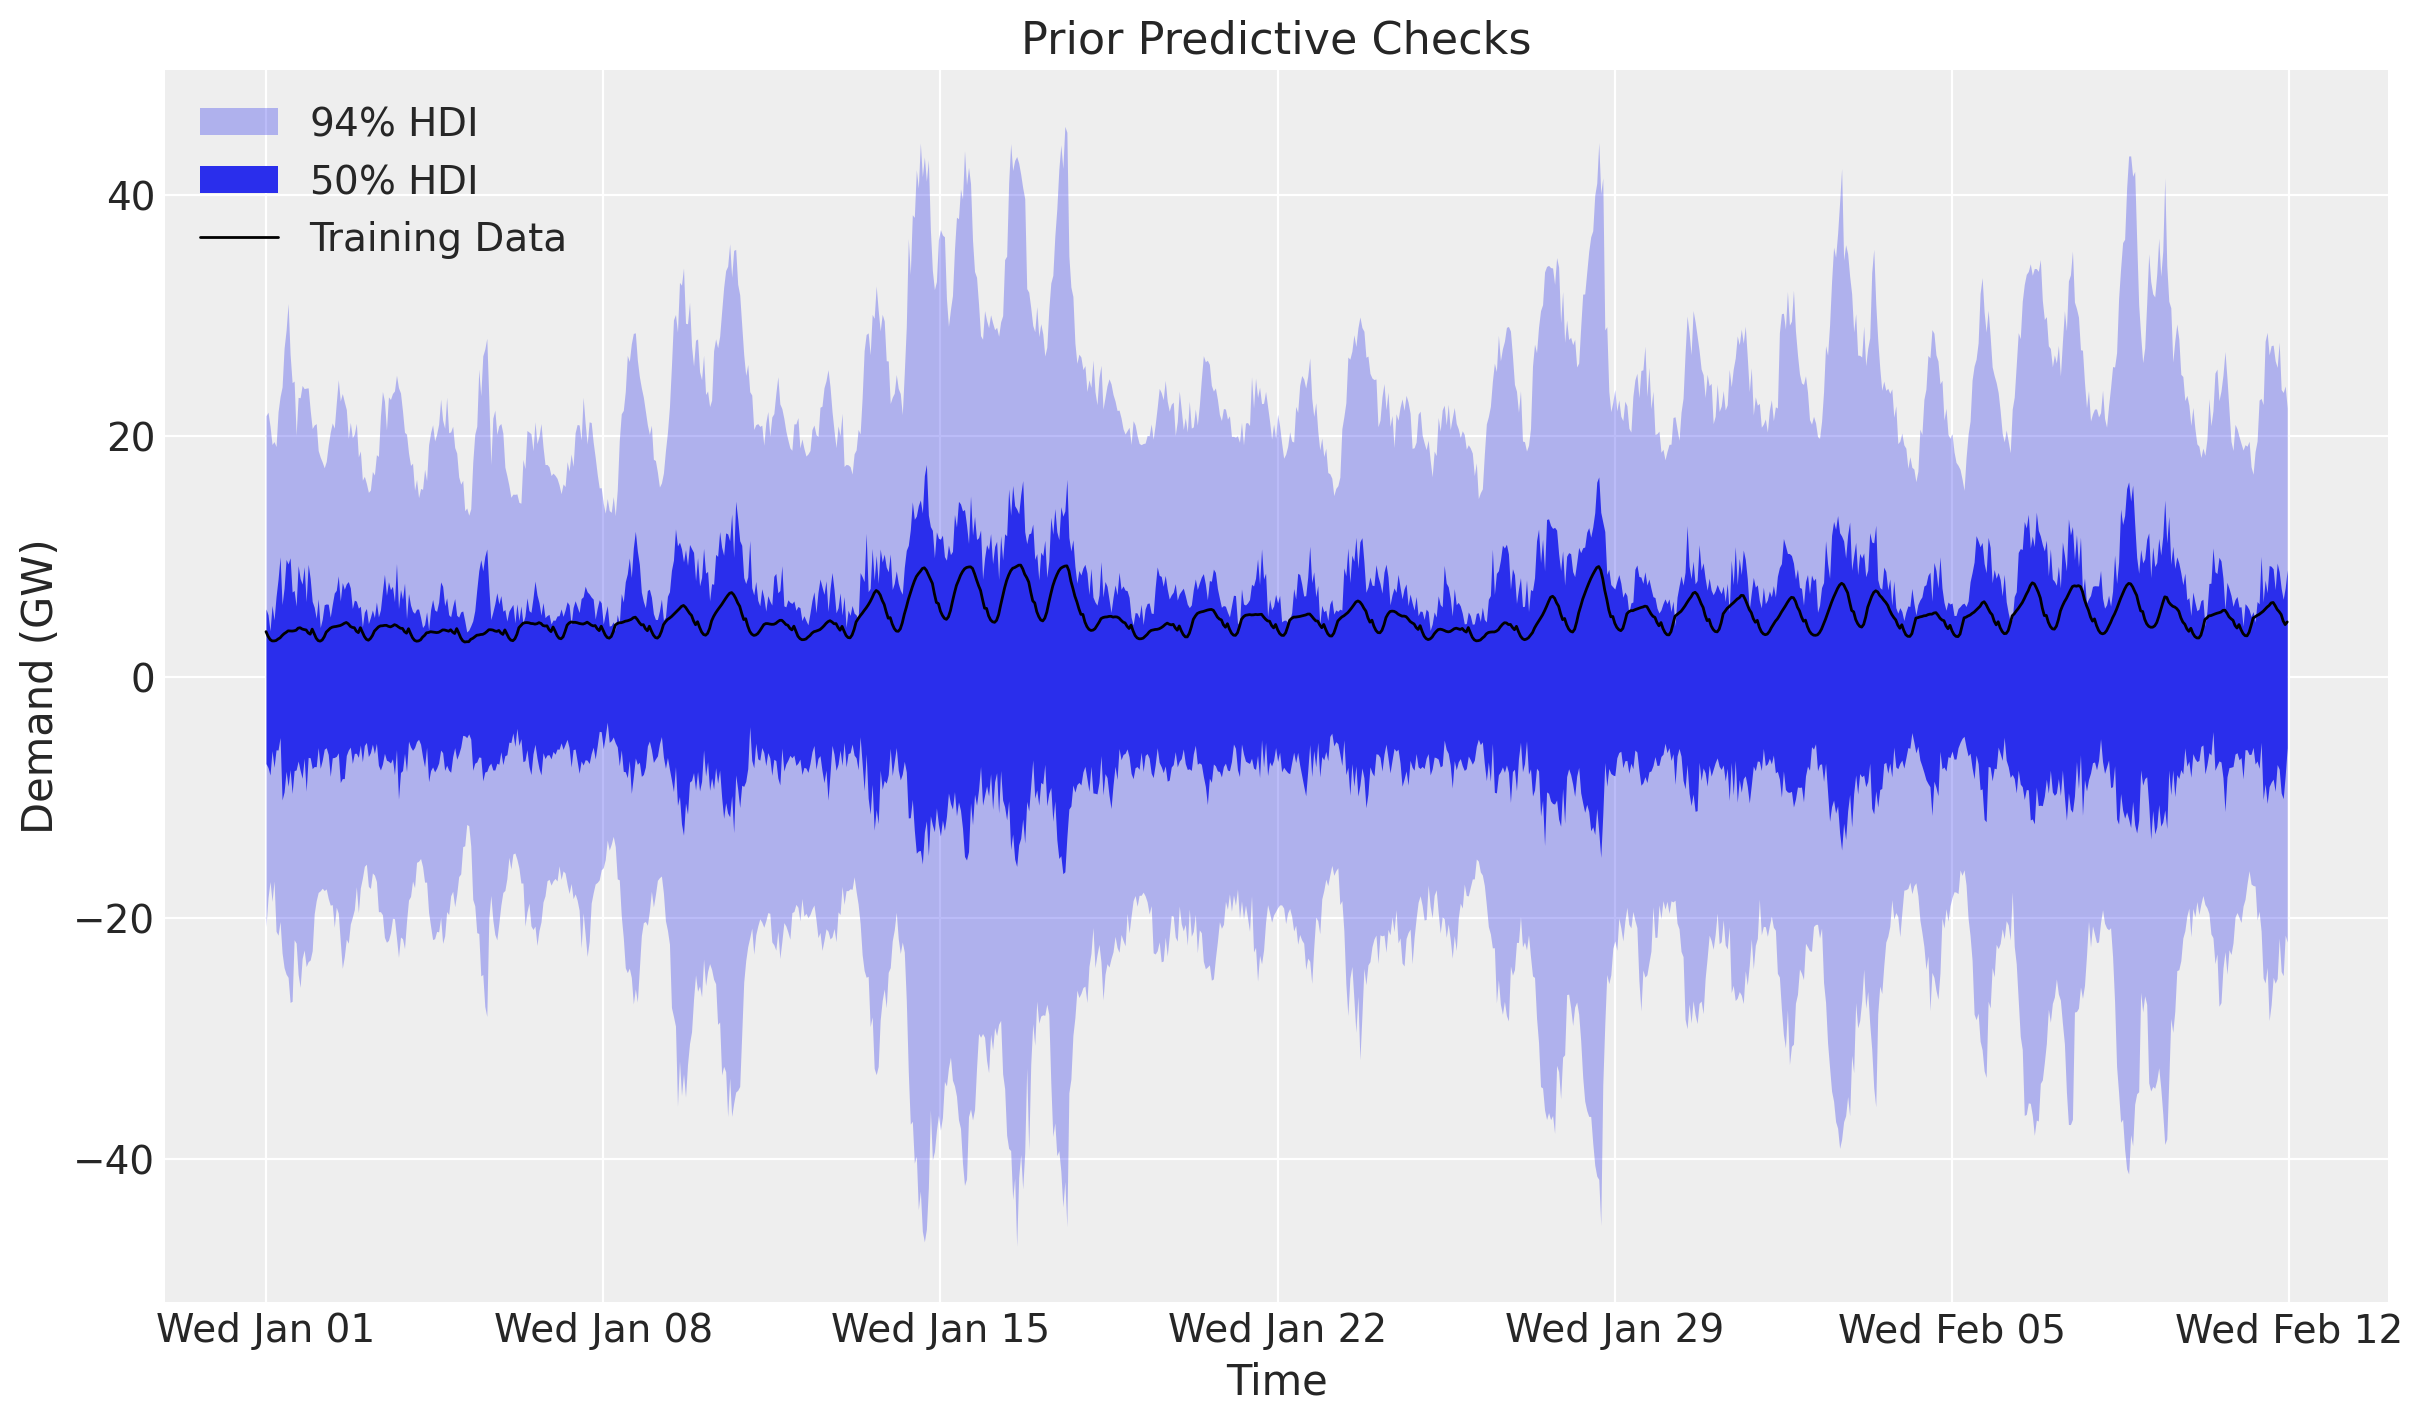

In [13]:
prior_predictive = Predictive(electricity_model, num_samples=2_000, return_sites=["obs"])
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"][..., 0]

xnum_train = mdates.date2num(dates_train)

idata_prior = az.from_dict(
    {
        "prior_predictive": {"obs": np.asarray(prior_obs)[None]},
        "observed_data": {"obs": np.asarray(data_train[:, 0])},
        "constant_data": {"date": xnum_train},
    },
    coords={"time": xnum_train},
    dims={"obs": ["time"], "date": ["time"]},
)
pc = az.plot_lm(
    idata_prior,
    y="obs",
    x="date",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
ax = pc.viz["figure"].item().axes[0]
bands = pc.viz["ci_band"]["date"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
(train_line,) = ax.plot(
    xnum_train, np.asarray(data_train[:, 0]), c="black", lw=1, label="Training Data"
)
ax.xaxis.set_major_locator(demand_loc)
ax.xaxis.set_major_formatter(demand_fmt)
ax.legend(handles=[band_94, band_50, train_line])
ax.set(title="Prior Predictive Checks", ylabel="Demand (GW)", xlabel="Time");

The prior predictive distribution is not too far from the training data but is not very restrictive either.

## Inference with SVI

We fit the model with plain NumPyro stochastic variational inference: an `AutoNormal` guide, `Adam`, and `SVI.run`, which returns the fitted `params` and the ELBO `losses`. The posterior is multimodal: the multiplicative `beta_temperature * temperature` term trades off against the overall level, so a guide initialized at random can settle on a monotonic temperature effect. We initialize the guide at a feasible point (`init_to_feasible`), which reliably recovers the heating-and-cooling (U-shaped) effect.

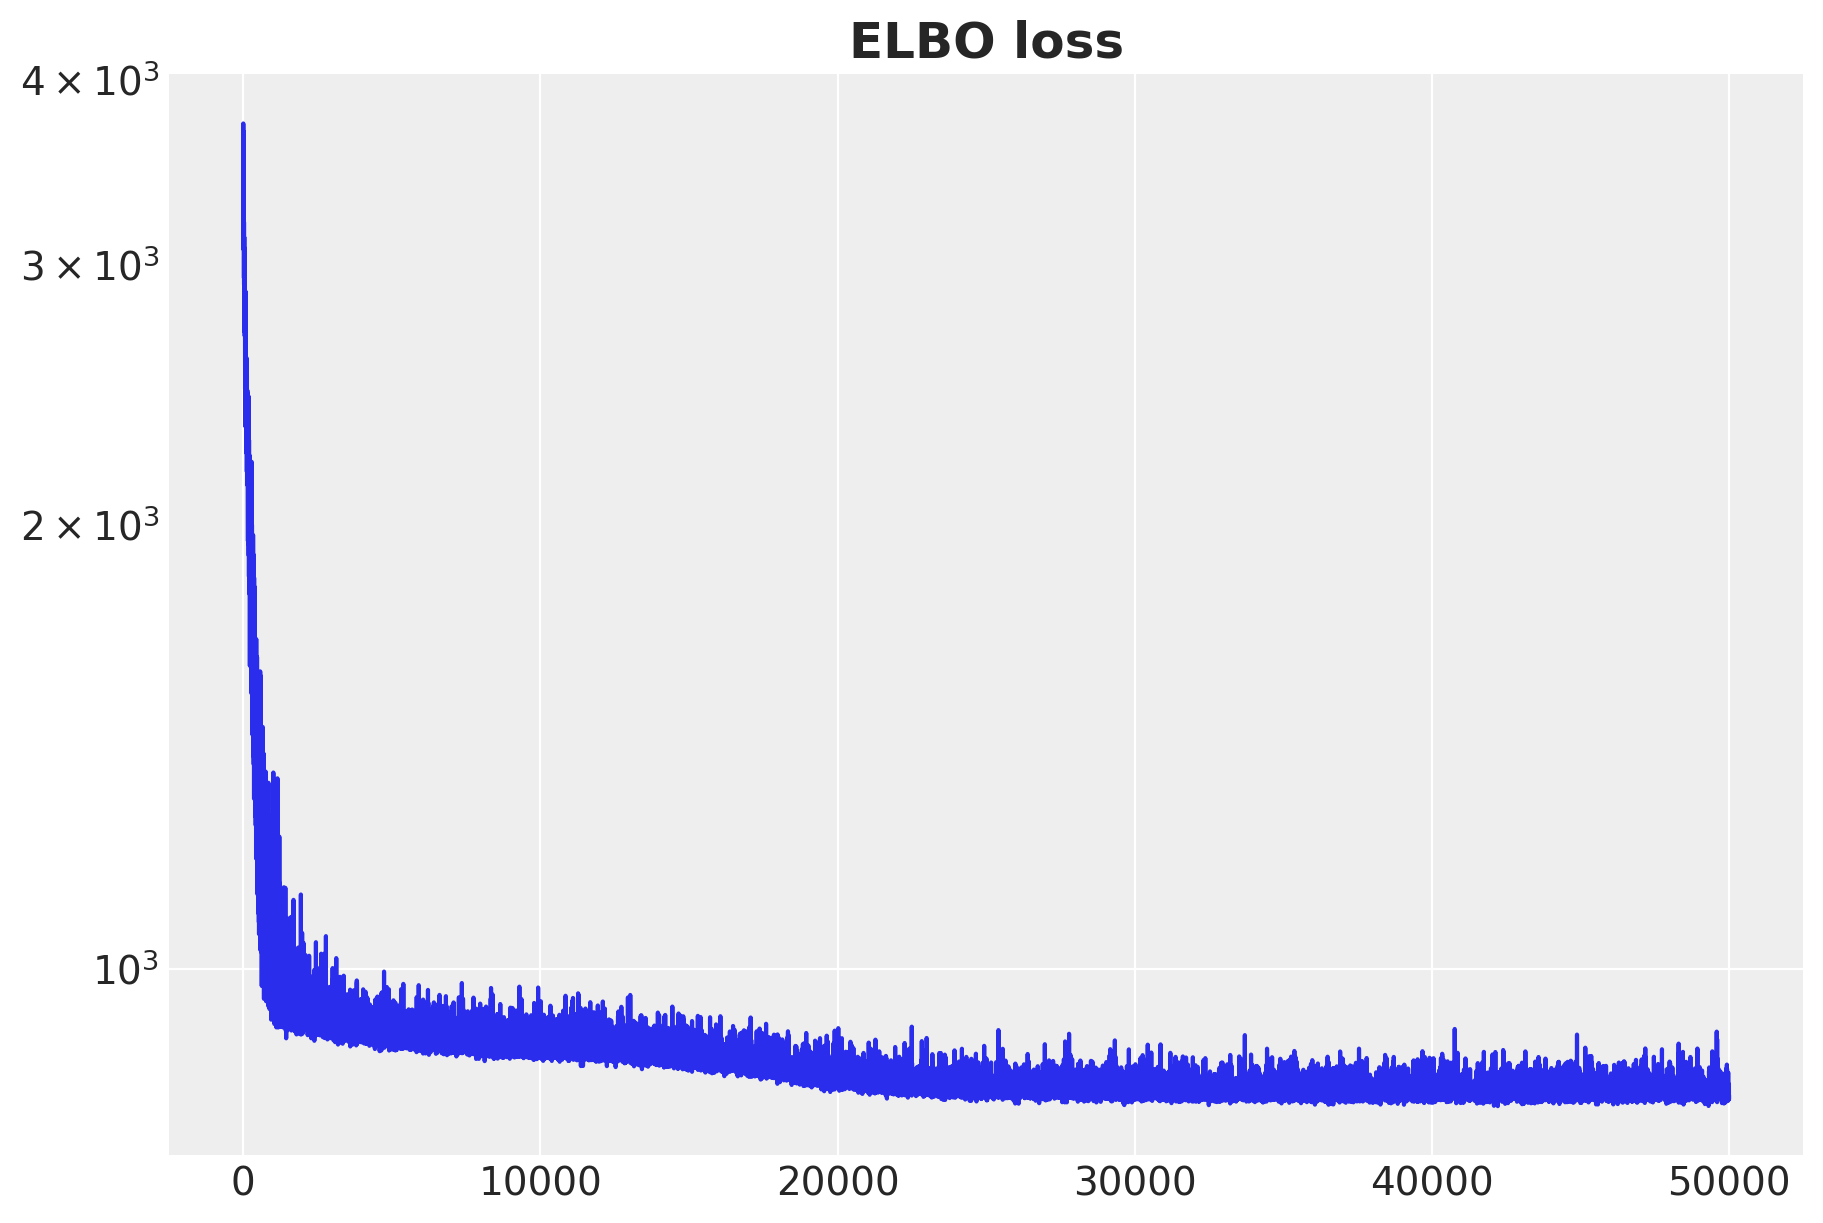

In [14]:
rng_key, rng_subkey = random.split(rng_key)
guide = AutoNormal(electricity_model, init_loc_fn=init_to_feasible)
svi = SVI(electricity_model, guide, Adam(step_size=0.005), Trace_ELBO())
svi_result = svi.run(rng_subkey, 50_000, covariates_train, data_train, progress_bar=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(svi_result.losses)
ax.set_yscale("log")
ax.set_title("ELBO loss", fontsize=18, fontweight="bold");

The ELBO loss is decreasing as expected.

## Posterior predictive checks

We now draw posterior latents from the fitted guide with `draw_posterior`, push them through the model over the training window with `predict_in_sample`, and forecast the held-out two weeks with `forecast` and the full-horizon covariates. `draw_posterior` returns the deterministic sites along with the latents, so the posterior dictionary already carries `beta_temperature` for the temperature-effect plot later.

In [15]:
num_posterior_samples = 5_000

rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)
posterior = draw_posterior(key_post, guide, svi_result.params, num_posterior_samples)
train_pp = predict_in_sample(key_pp, electricity_model, posterior, covariates_train)
forecast_draws = forecast(key_fc, electricity_model, posterior, data_train, covariates)

### Forecast evaluation

We score the train and test forecasts with `evaluate_forecast`, which reports several metrics at once: CRPS (the [Continuous Ranked Probability Score](https://en.wikipedia.org/wiki/Scoring_rule#Continuous_ranked_probability_score)), mean absolute error, root mean squared error, and the empirical coverage of the central $90\%$ prediction interval.

In [16]:
train_metrics = evaluate_forecast(train_pp, data_train)
test_metrics = evaluate_forecast(forecast_draws, data_test)

metrics_table = pd.DataFrame({"train": train_metrics, "test": test_metrics})
metrics_table

,train,test
mae,0.375093,0.258412
rmse,0.510386,0.325775
crps,0.273276,0.187728
coverage,0.918651,0.994048


The held-out scores land in the same ballpark as the in-sample ones (here even a touch sharper), and the central $90\%$ interval is well calibrated in-sample (coverage near `0.9`) and conservative out-of-sample, so the model generalizes to the held-out two weeks rather than overfitting. We can now compare the posterior predictive distribution with the training and test data.

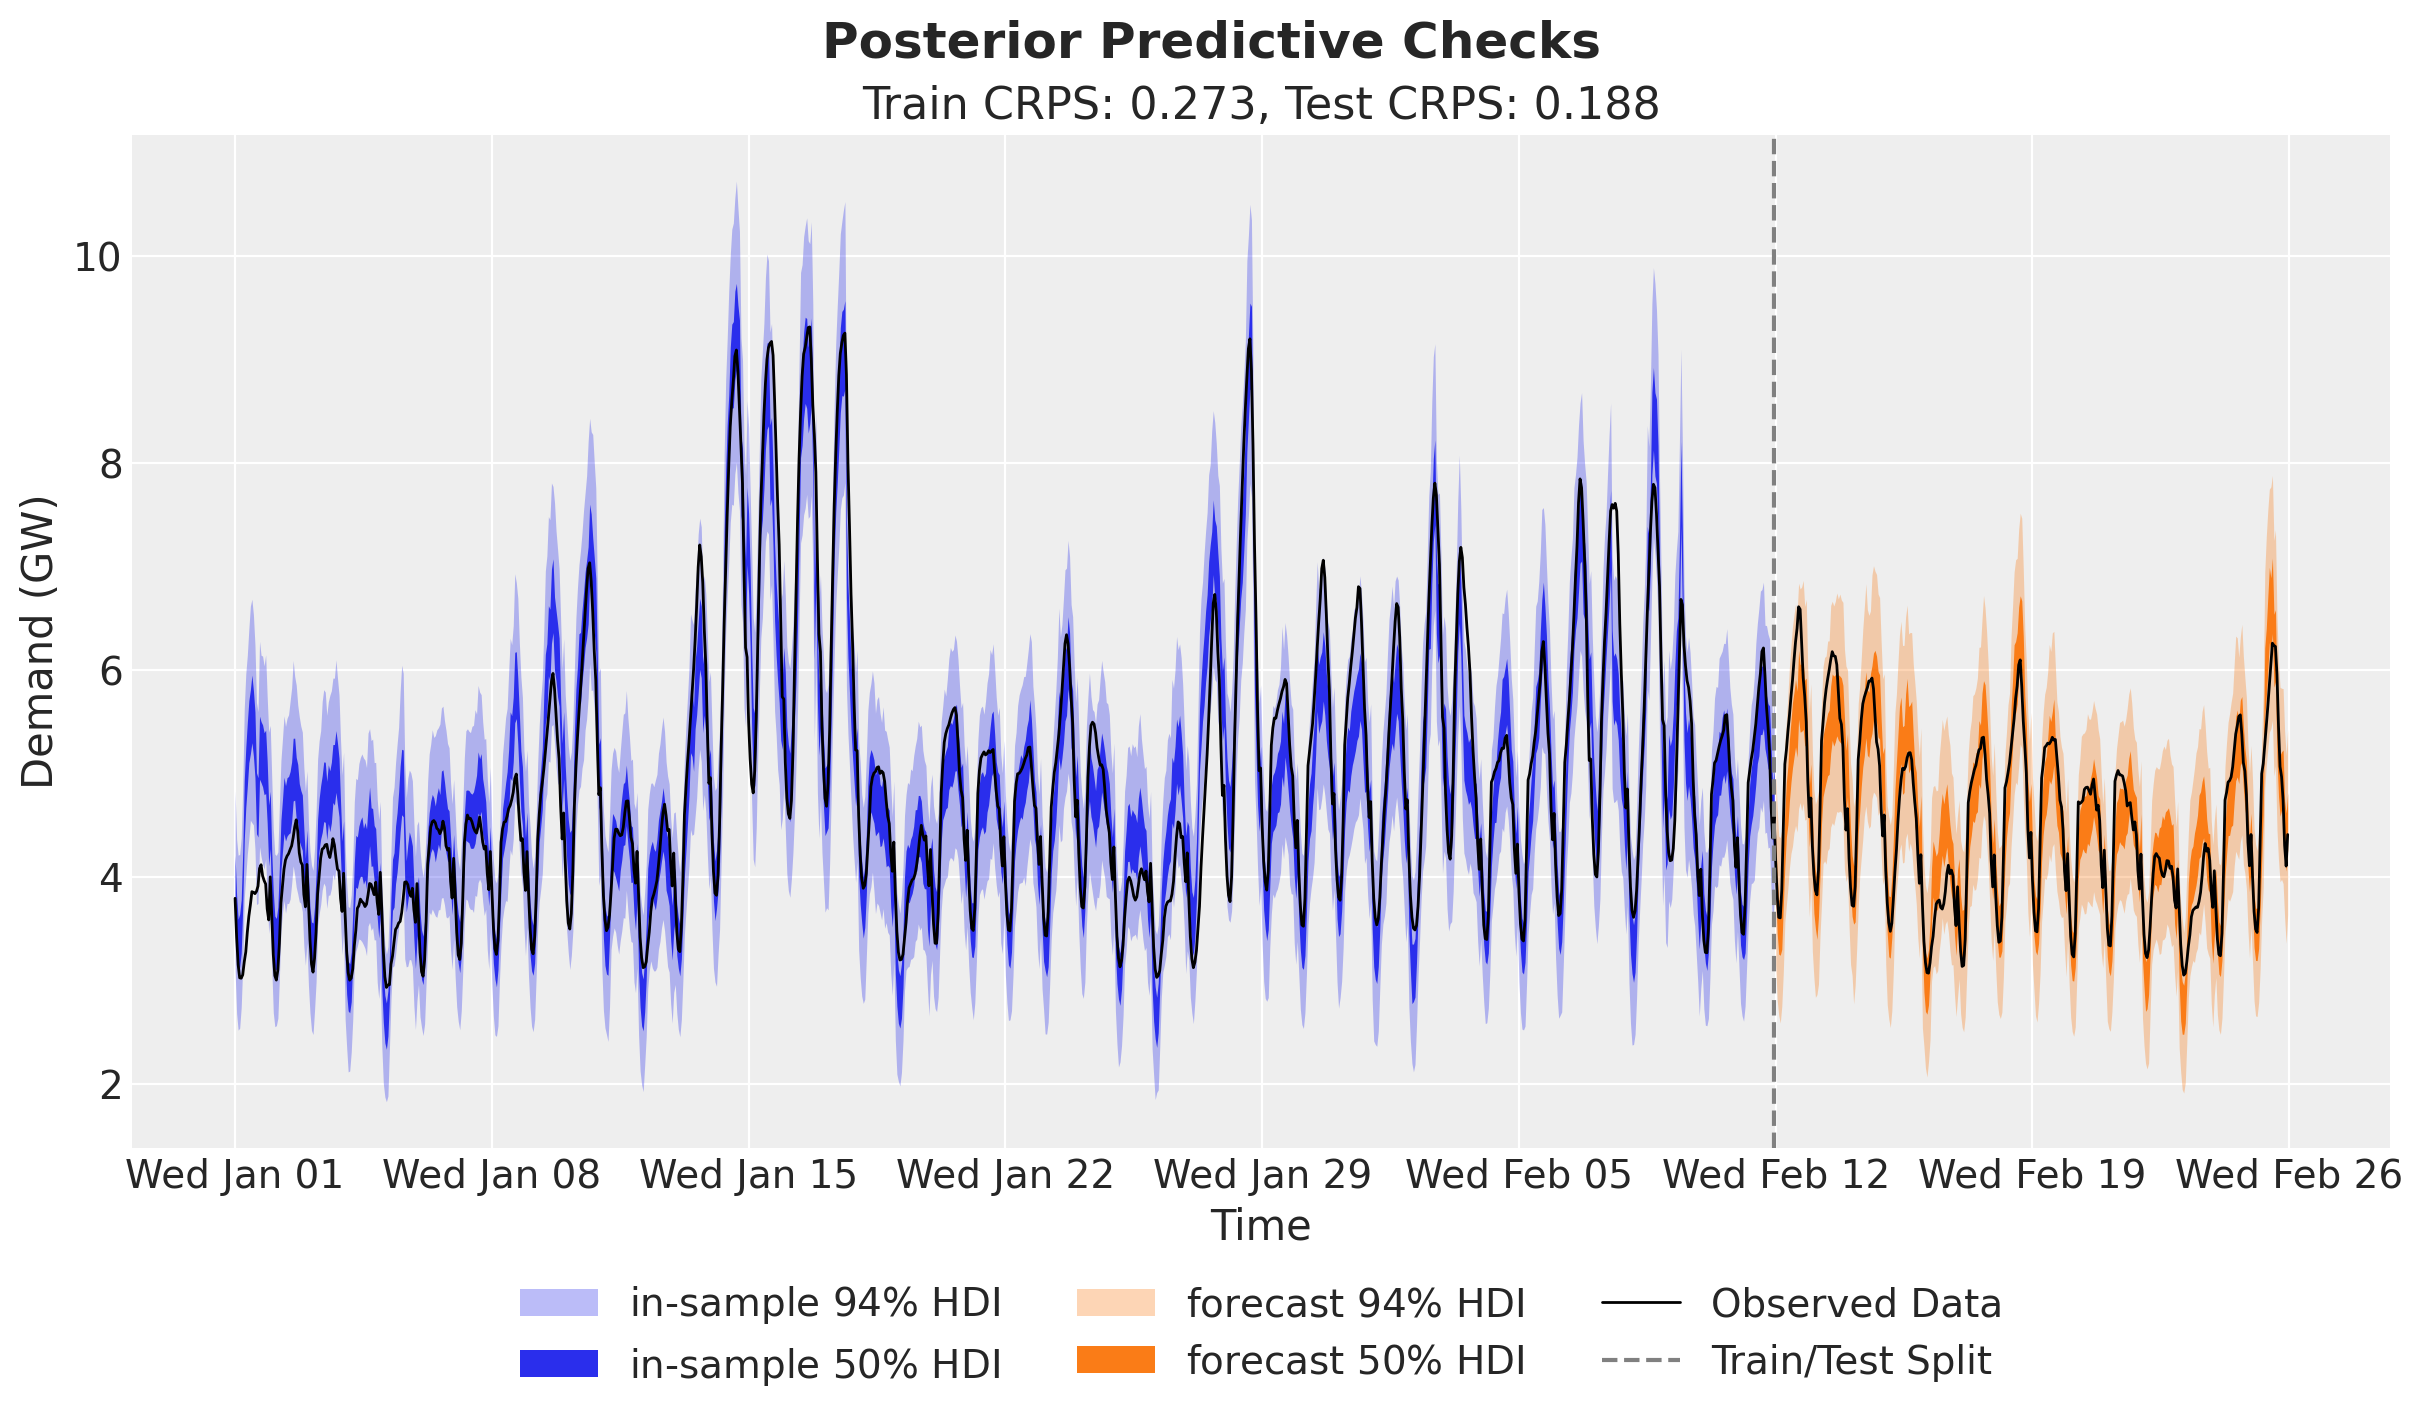

In [17]:
train_obs = train_pp[..., 0]
forecast_obs = forecast_draws[..., 0]

xnum_test = mdates.date2num(dates_test)

idata_train = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(train_obs)[None]},
        "observed_data": {"obs": np.asarray(data_train[:, 0])},
        "constant_data": {"date": xnum_train},
    },
    coords={"time": xnum_train},
    dims={"obs": ["time"], "date": ["time"]},
)
idata_test = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(forecast_obs)[None]},
        "observed_data": {"obs": np.asarray(data_test[:, 0])},
        "constant_data": {"date": xnum_test},
    },
    coords={"time": xnum_test},
    dims={"obs": ["time"], "date": ["time"]},
)

pc = az.plot_lm(
    idata_train,
    y="obs",
    x="date",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
train_bands = pc.viz["ci_band"]["date"]
band_train_94 = train_bands.sel(prob=0.94).item()
band_train_50 = train_bands.sel(prob=0.5).item()
az.plot_lm(
    idata_test,
    y="obs",
    x="date",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
test_bands = pc.viz["ci_band"]["date"]
band_test_94 = test_bands.sel(prob=0.94).item()
band_test_50 = test_bands.sel(prob=0.5).item()
ax = pc.viz["figure"].item().axes[0]
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
obs_dates = mdates.date2num(np.concatenate([dates_train, dates_test]))
obs_values = np.concatenate([np.asarray(data_train[:, 0]), np.asarray(data_test[:, 0])])
(obs_line,) = ax.plot(obs_dates, obs_values, c="black", lw=1, label="Observed Data")
split_line = ax.axvline(x=xnum_train[-1], color="gray", linestyle="--", label="Train/Test Split")
ax.xaxis.set_major_locator(demand_loc)
ax.xaxis.set_major_formatter(demand_fmt)
ax.legend(
    handles=[band_train_94, band_train_50, band_test_94, band_test_50, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Train CRPS: {train_metrics['crps']:.3f}, Test CRPS: {test_metrics['crps']:.3f}",
    ylabel="Demand (GW)",
    xlabel="Time",
)
fig = pc.viz["figure"].item()
fig.suptitle("Posterior Predictive Checks", fontsize=18, fontweight="bold");

The predictions look very good, and clearly better than the basic linear model used in the TensorFlow Probability tutorial (which is fine, as they focus on the core API).

### Temperature effect on demand

Being happy about the forecast performance, we can dig deeper into the temperature effect. First we simply plot the predictions and the raw values against temperature, sorting by temperature so the HDI band reads cleanly.

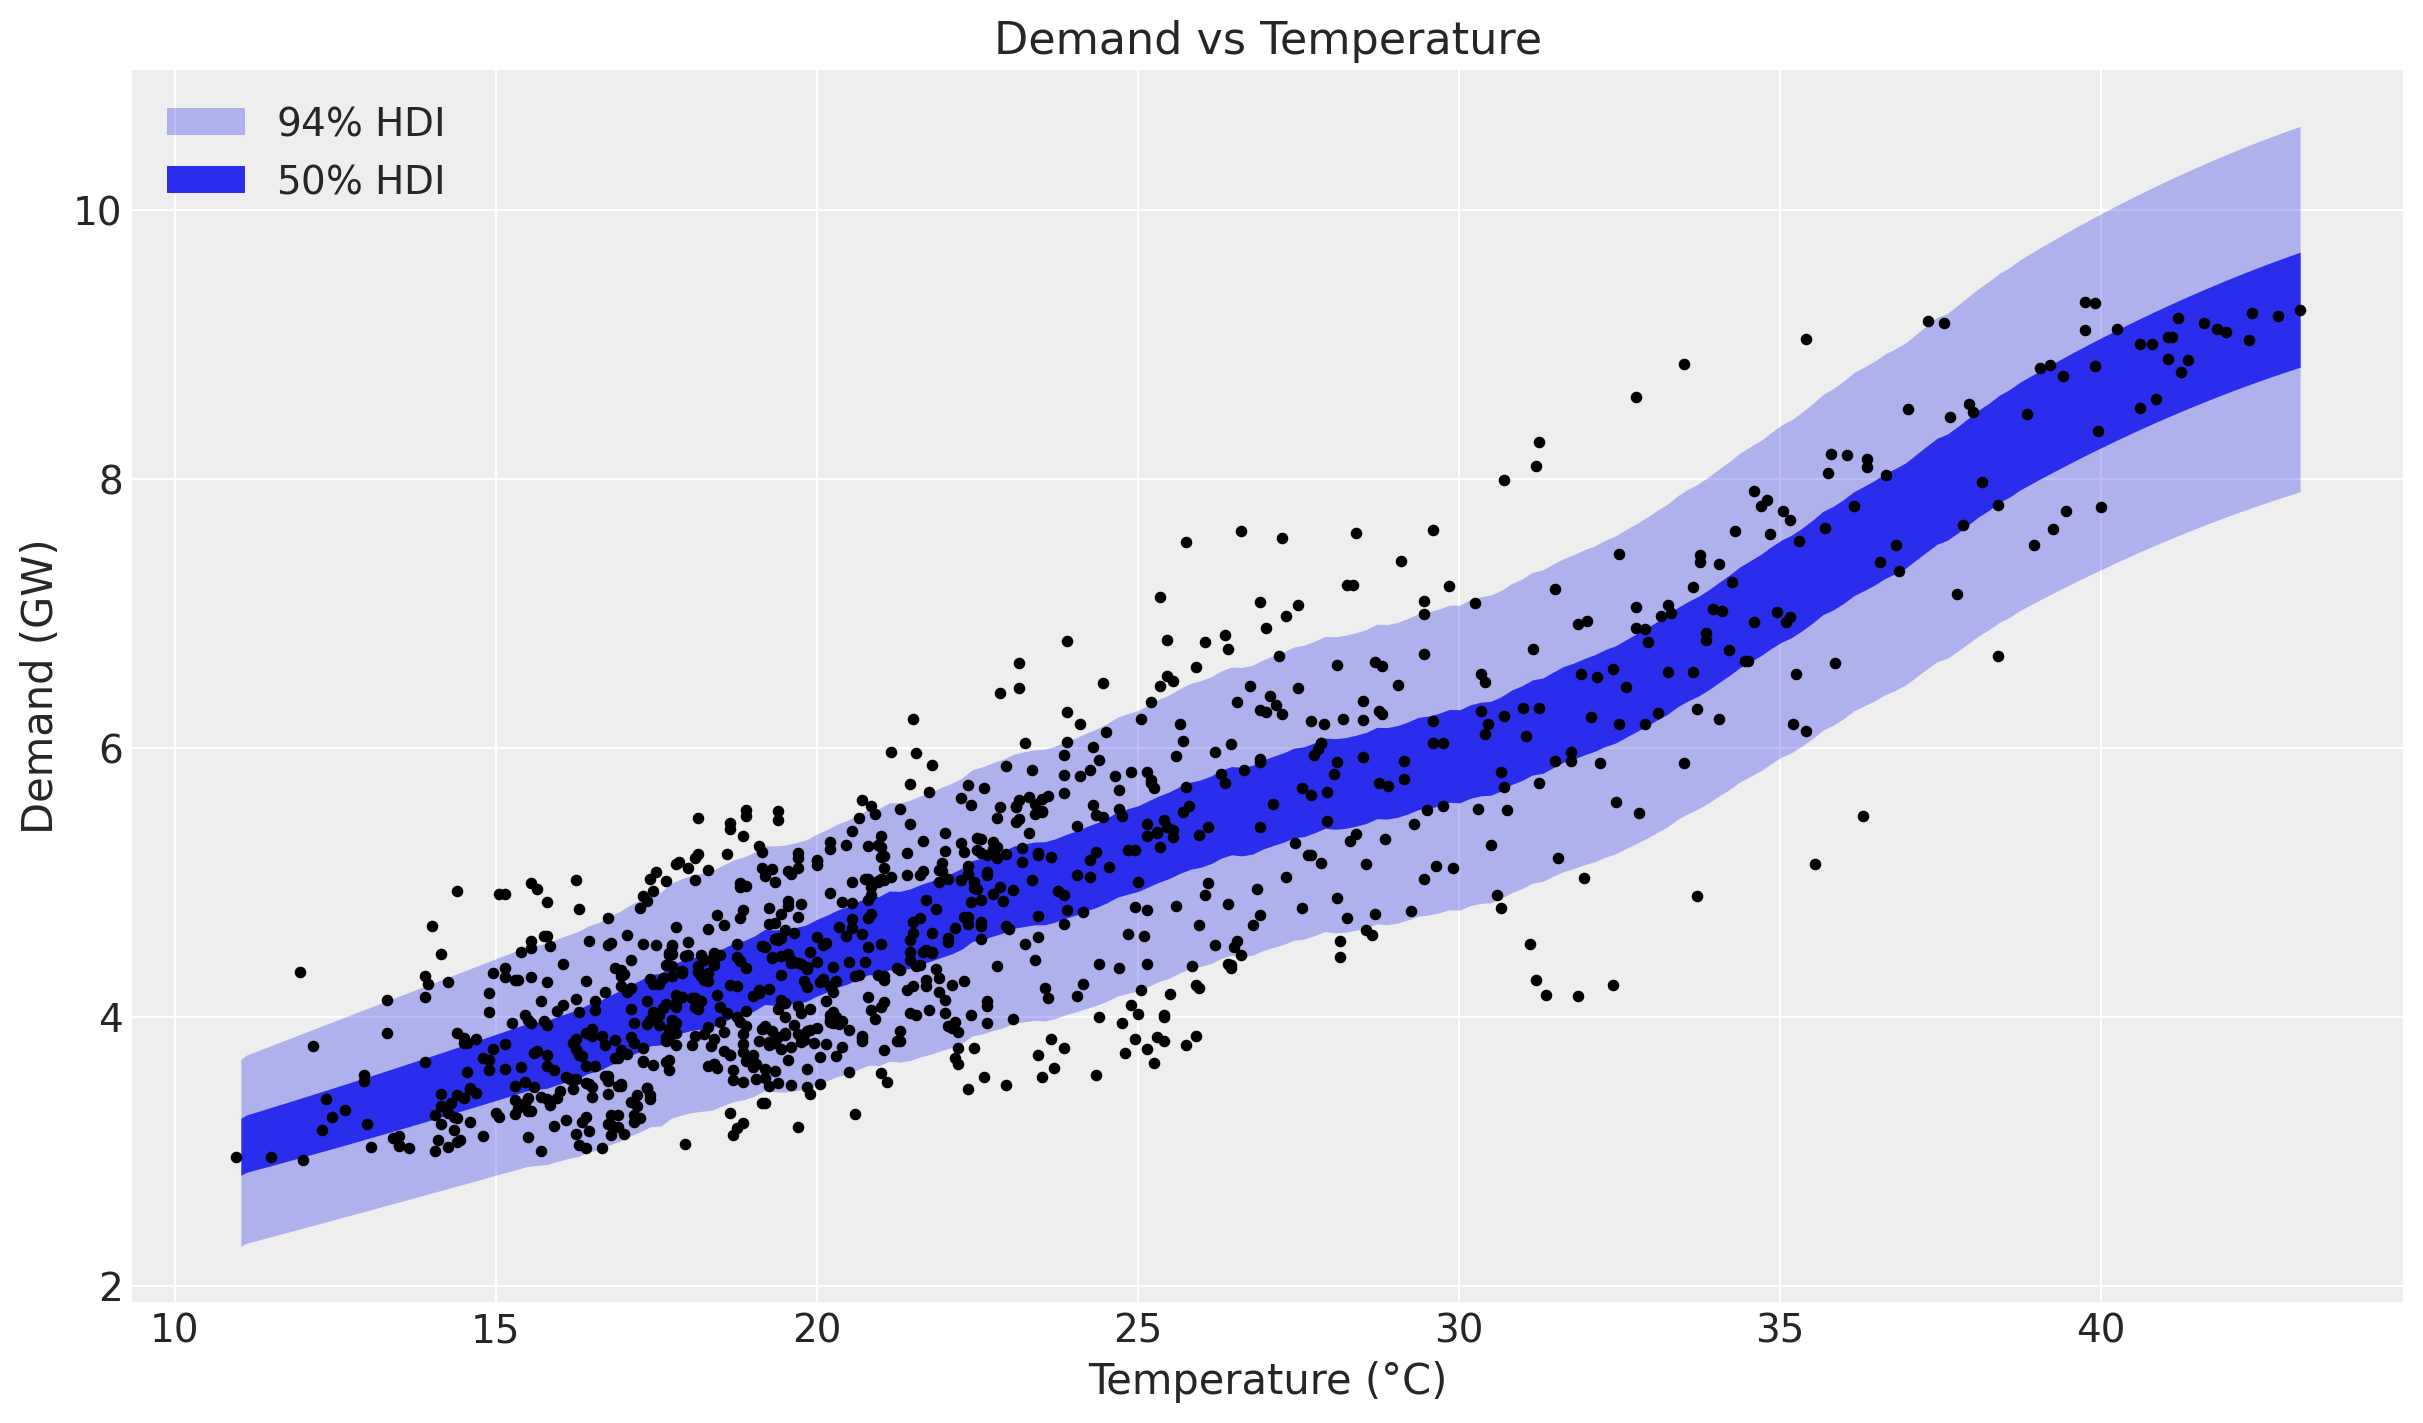

In [18]:
temperature_train = np.asarray(temperature[:t_train])
order = np.argsort(temperature_train)

idata_demand = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(train_obs[:, order])[None]},
        "observed_data": {"obs": np.asarray(data_train[order, 0])},
        "constant_data": {"temperature": temperature_train[order]},
    },
    dims={"obs": ["obs_dim"], "temperature": ["obs_dim"]},
)
pc = az.plot_lm(
    idata_demand,
    y="obs",
    x="temperature",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
ax = pc.viz["figure"].item().axes[0]
bands = pc.viz["ci_band"]["temperature"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
ax.scatter(temperature_train, np.asarray(data_train[:, 0]), c="black", s=10)
ax.legend(handles=[band_94, band_50])
ax.set(title="Demand vs Temperature", xlabel="Temperature (°C)", ylabel="Demand (GW)");

The non-linearity is clearly visible. Next we look at the latent relationship between temperature and demand: the posterior distribution of the Gaussian Process component `beta_temperature`.

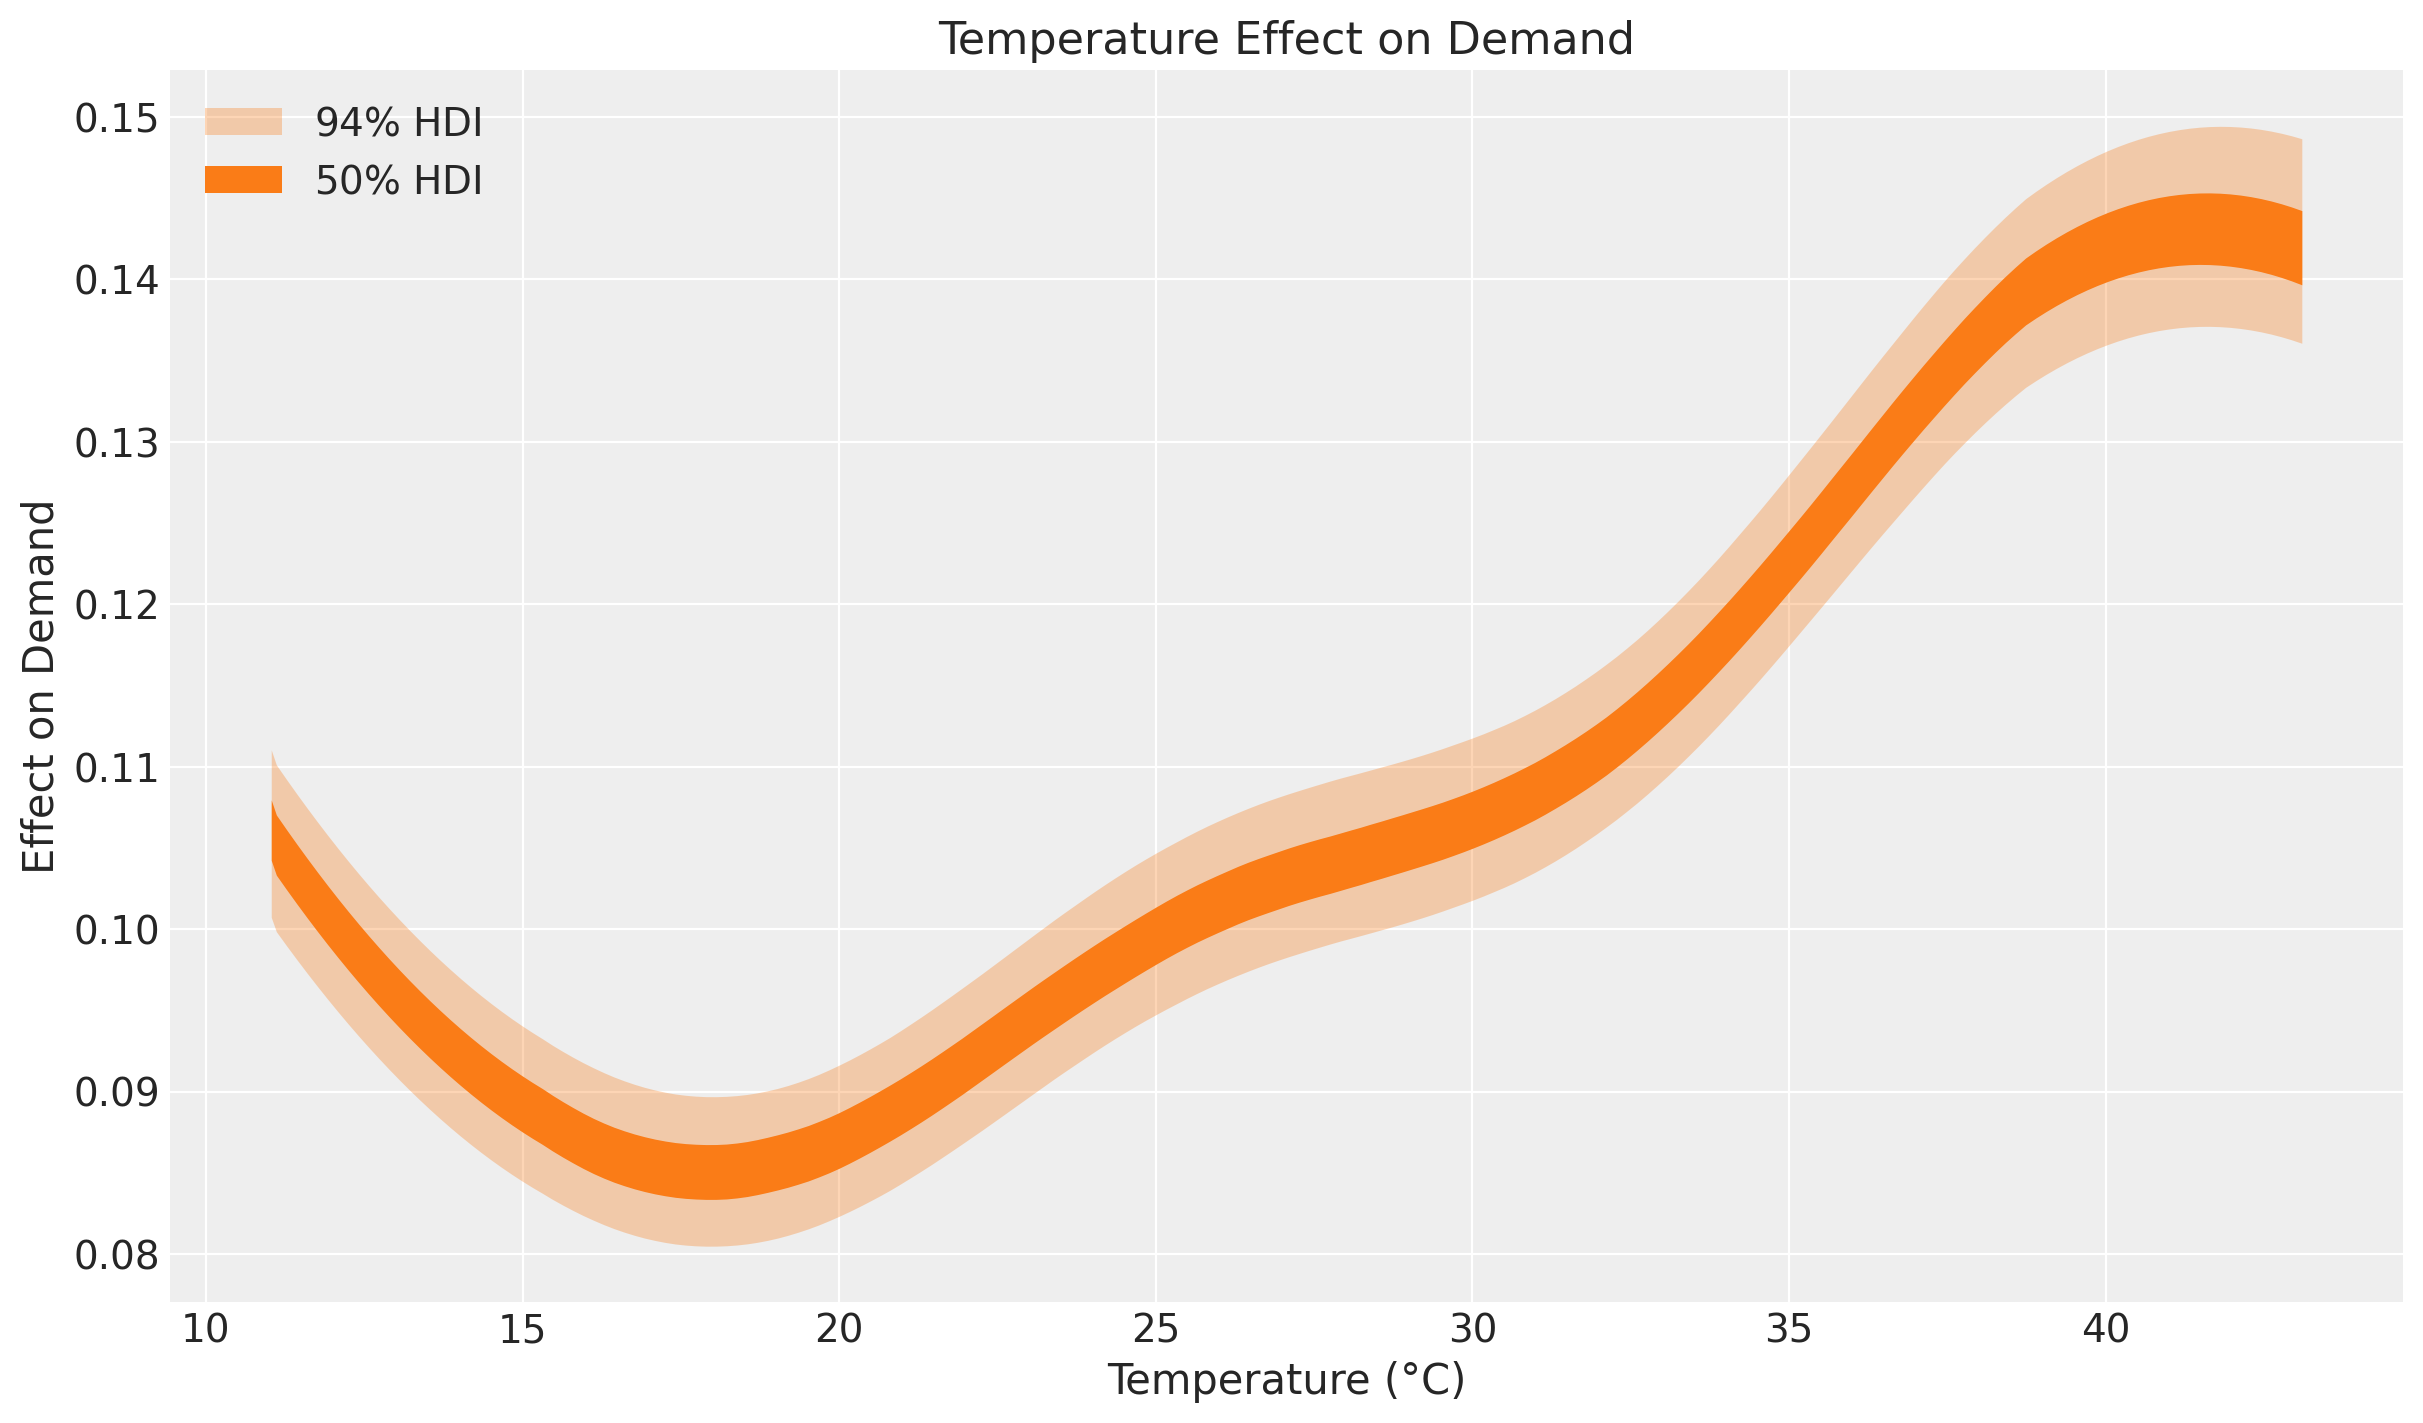

In [19]:
beta_temperature = posterior["beta_temperature"]

idata_beta = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(beta_temperature[:, order])[None]},
        "observed_data": {"obs": np.zeros_like(temperature_train[order])},
        "constant_data": {"temperature": temperature_train[order]},
    },
    dims={"obs": ["obs_dim"], "temperature": ["obs_dim"]},
)
pc = az.plot_lm(
    idata_beta,
    y="obs",
    x="temperature",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
ax = pc.viz["figure"].item().axes[0]
bands = pc.viz["ci_band"]["temperature"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
ax.legend(handles=[band_94, band_50])
ax.set(title="Temperature Effect on Demand", xlabel="Temperature (°C)", ylabel="Effect on Demand");

This effect plot coincides with the exploratory comment by Hyndman and Athanasopoulos at https://otexts.com/fpp2/scatterplots.html:

> *"It is clear that high demand occurs when temperatures are high due to the effect of air-conditioning. But there is also a heating effect, where demand increases for very low temperatures."*

Indeed, at the extremes of the common temperature range the temperature effect on demand increases. Heating and cooling usually happen outside the range $15\,°C - 25\,°C$.

## References

- Orduz, J. [*Electricity Demand Forecast: Dynamic Time-Series Model*](https://juanitorduz.github.io/electricity_forecast/).
- Orduz, J. [*Time-Varying Regression Coefficients via Hilbert Space Gaussian Process Approximation*](https://juanitorduz.github.io/bikes_gp/).
- TensorFlow Probability. [*Structural Time Series Modeling Case Studies: Atmospheric CO2 and Electricity Demand*](https://www.tensorflow.org/probability/examples/Structural_Time_Series_Modeling_Case_Studies_Atmospheric_CO2_and_Electricity_Demand), using the [`tfp.sts`](https://www.tensorflow.org/probability/api_docs/python/tfp/sts) module.
- NumPyro. [*Hilbert Space Gaussian Processes approximation*](https://num.pyro.ai/en/stable/contrib.html#hilbert-space-gaussian-processes-approximation).
- Hyndman, R. J., & Athanasopoulos, G. [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/).
- [*Continuous Ranked Probability Score*](https://en.wikipedia.org/wiki/Scoring_rule#Continuous_ranked_probability_score) (Wikipedia).